# NB63B: evaluating the creation of map and sparse grids for interpolation over low resolution physics variations grids (var grids)

This notebook adapts some parts of NB63 to evaluate the production of sparse grids for physics variations. It checks for CHE window shape capture with map grids, and good behavior of the interpolator over sparse grids sampled from map grids, for different physics variations.

This notebook expects to a lod a ```.h5``` file generated with ```../scripts/get_core_properties_v7.py```.

In [1]:
nb_id = "63b"

## Setup

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import sys
sys.path.append('..')
from src.binary import eggleton_rl1_radius, a_from_p, marchant_l2_radius
from src.util import DATA_DIR, MESA_DATA_DIR, build_logbump35_cmap, savefig_base
from src.constants import Z_SUN
FIGURE_FOLDER = Path(f'../figures/nb{nb_id}')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

OUTPUT_FOLDER = DATA_DIR / 'nb_output' / f'nb{nb_id}'
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
plt.style.use('./plotstyle.mplstyle')
pd.set_option('display.max_columns', None)

In [3]:
def savefig(fig, fname):
    savefig_base(fig, fname, nb_id, FIGURE_FOLDER)

In [4]:
from src.popsynth import PMZLinearInterpolator, PMZWindPileupModel, get_complete_core_props_df, plot_pmz_mass_time_diagnostic, cross_validate_pmz, plot_pmz_cv_diagnostic, plot_pmz_interpolator_fit

## 1. Definitions

Compare interpolator to grid, along each of the three input axes (`m_zams`, `p_spin_zams`, `z`), over different target variables.

In [5]:
core_props_df = get_complete_core_props_df(DATA_DIR/'01_weakmix_core_props_df_map_v7.h5')
model_name = '01_weakmix_map'
map_core_props_df = core_props_df  # kept around to show as a background layer under the sparse grid (section 3)

In [6]:
import matplotlib.patheffects as pe
from src.popsynth import _predict_get_var

# The commented out lines are variables used in the full pipeline 
# however the map grid does not even complete the Main Sequence,
# and is used only to interpolate to m_f and produce the sparse grid.
# PIPELINE_VARS = ['m_f', 'x_f', 'log_t_d', 'm_cocore_tahems']
PIPELINE_VARS = ["m_f"]

# Set up interpolator without cutting non He depl, otherwise it will ignore the entire map grid.
ip_models = {
    var: PMZLinearInterpolator(
        core_props_df, var=var, cut_non_he_depl=False, extrapolate_z_islands=True,
    )
    for var in PIPELINE_VARS
}

Z_KEYS = sorted(ip_models['m_f'].p_interpolators.keys(), key=float)[0:]
Z_GRID_MIN = float(Z_KEYS[0])
print('grid metallicity slices:', Z_KEYS)

grid metallicity slices: ['0.0050', '0.0100', '0.0200', '0.0400', '0.0800', '0.1000', '0.2000', '0.3000', '0.4000']


/tmp/ipykernel_536494/4004843127.py:12: UserWarning: [PMZLinearInterpolator var=m_f] 9 (m, p) column(s) whose valid metallicities form one run reaching neither metallicity global minimum nor maximum. Is this a broad CHE window cusp or error? Interpolator will continue. Cells: (45, 0.7, XXOOXXXXX), (50, 0.7, XOOXXXXXX), (50, 0.8, XXXOOOXXX), (60, 0.9, XXOOOOOXX), (70, 1, XXOOOOOXX), (80, 1, XOOOOOXXX), (90, 1.1, XOOOOOOXX), (300, 1.6, XOOOOOOOX), ... (+1 more)
  var: PMZLinearInterpolator(
/tmp/ipykernel_536494/4004843127.py:12: UserWarning: [PMZLinearInterpolator var=m_f] 7 (m, p) column(s) whose valid metallicities form two or more separate runs. Check input data for crashed CHE cases. Interpolator will smooth over gaps. Cells: (160, 1.3, OOOOOOXOX), (180, 1.2, OOOOXXOXX), (200, 1.2, OOOOXOXXX), (220, 1.2, OOOXOOXXX), (220, 1.3, OOOOOXOXX), (240, 1.2, OOOXOXXXX), (260, 1.2, OOXOXXXXX)
  var: PMZLinearInterpolator(


In [7]:
### HELPER FUNCTIONS ###
# Collection of helper functions to evaluate grid coverage and interpolator behavior.

from concurrent.futures import ProcessPoolExecutor

def pmz_slice_values(model, m_grid, p_grid):
    """Evaluate the 3d PMZ interpolator's mass interpolators on a M,P mesh, per Z slice.

    Returns (values, z_keys) with `values` of shape
    (len(p_grid), len(m_grid), len(z_keys)) and `z_keys` sorted ascending in Z.
    Entry [j, i, k] is what metallicity slice `z_keys[k]` alone would return at
    (m_grid[i], p_grid[j]), or NaN where that slice has no CHE coverage.

    This is meant to isolate and verify behavior of M,P, as metallicity introduces
    extra complications to the CHE window shape variation over Z. Unlike 
    `scan_pmz_model`, this skips the internal Z-handling logic of `PMZLinearInterpolator`.
    """
    m_grid = np.asarray(m_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    z_keys = sorted(model.p_interpolators.keys(), key=float)
    values = np.full((len(p_grid), len(m_grid), len(z_keys)), np.nan)
    for j, p0 in enumerate(p_grid):
        for k, z_key in enumerate(z_keys):
            values[j, :, k] = model._get_m_interpolator(float(p0), z_key)(m_grid)
    return values, z_keys


def pmz_source_z_grid(model, m_grid, p_grid, slice_values=None, z_keys=None):
    """Return source metallicity for interpolator calls below grid Z minimum.

    Meant to check that only the grid Z minimum ever gets extrapolated down.
    Returns (source_idx, z_keys, n_valid).
    """
    if slice_values is None:
        slice_values, z_keys = pmz_slice_values(model, m_grid, p_grid)
    valid = ~np.isnan(slice_values)
    n_valid = valid.sum(axis=2)
    source_idx = np.where(n_valid > 0, valid.argmax(axis=2), -1)
    return source_idx, z_keys, n_valid


def _scan_pmz_worker(args):
    """Top-level (picklable) worker: scan a chunk of p_grid rows at fixed `z`."""
    model, m_grid, p_chunk, z = args
    out = np.full((len(p_chunk), len(m_grid)), np.nan)
    for j, p0 in enumerate(p_chunk):
        for i, m0 in enumerate(m_grid):
            try:
                out[j, i] = float(model.get_var(float(m0), float(p0), float(z)))
            except Exception:
                pass
    return out


def scan_pmz_model(model, m_grid, p_grid, z, cache_path=None, n_cpu=1):
    """PMZLinearInterpolator-consistent scan over an (m_grid × p_grid) mesh at fixed `z`.

    Each (m, p) point is an independent `model.get_var` call. With `n_cpu > 1`,
    p_grid is split into `n_cpu` row-chunks and scanned in parallel worker
    processes (`concurrent.futures.ProcessPoolExecutor`).
    """
    m_grid = np.asarray(m_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    if cache_path is not None:
        cache_path = Path(cache_path)
        if cache_path.exists():
            cached = np.load(cache_path)
            same = (
                cached["m_grid"].shape == m_grid.shape
                and np.allclose(cached["m_grid"], m_grid)
                and cached["p_grid"].shape == p_grid.shape
                and np.allclose(cached["p_grid"], p_grid)
                and np.isclose(float(cached["z"]), float(z))
            )
            if same:
                return cached["values"]

    if n_cpu and n_cpu > 1:
        p_chunks = [c for c in np.array_split(p_grid, n_cpu) if len(c)]
        with ProcessPoolExecutor(max_workers=n_cpu) as ex:
            chunk_results = list(
                ex.map(_scan_pmz_worker, [(model, m_grid, chunk, z) for chunk in p_chunks])
            )
        values = np.vstack(chunk_results)
    else:
        values = np.full((len(p_grid), len(m_grid)), np.nan)
        for j, p0 in enumerate(p_grid):
            for i, m0 in enumerate(m_grid):
                try:
                    values[j, i] = float(model.get_var(float(m0), float(p0), float(z)))
                except Exception:
                    pass

    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez(cache_path, values=values, m_grid=m_grid, p_grid=p_grid, z=float(z))
    return values


def _nearest_grid_index(grid, values):
    """Index of the closest entry of an ascending `grid` for each of `values`.
    
    Args:
        grid (array-like): An ascending array of grid points.
        values (array-like): Values to find the nearest grid index for.

    Returns:
        np.ndarray: Indices of the closest grid entries for each value.
    """
    grid = np.asarray(grid, dtype=float)
    values = np.asarray(values, dtype=float)
    hi = np.clip(np.searchsorted(grid, values), 1, len(grid) - 1)
    lo = hi - 1
    take_hi = np.abs(values - grid[hi]) < np.abs(values - grid[lo])
    return np.where(take_hi, hi, lo)


def floor_source_z_key(model, m_zams, p_spin_zams):
    """Return source Z-slice for an interpolator call below the grid Z minimum.

    Replicates internal selection logic of `PMZLinearInterpolator` for calls below
    the grid Z minimum, including the gap handling logic that is applied to grid 
    metallicity slices before checking for an available source slice. Also meant to
    check that only the minimum Z slice ever gets extrapolated to sub-grid Z.
    """
    z_keys = sorted(model.p_interpolators.keys(), key=float)
    ip_y = np.array([
        model._get_m_interpolator(p_spin_zams, z_key)(m_zams) for z_key in z_keys
    ])
    valid = ~np.isnan(ip_y)

    if model.extrapolate_z_islands and np.sum(valid) == 1:
        island_idx = np.where(valid)[0][0]
        z_island_key = z_keys[island_idx]
        nearest_m_key = min(
            model.p_interpolators[z_island_key].keys(),
            key=lambda k: abs(float(k) - m_zams),
        )
        p_ip = model.p_interpolators[z_island_key][nearest_m_key]
        if not np.isnan(p_ip.x[0]):
            at_short_p = (p_spin_zams - p_ip.x[0]) < (p_ip.x[-1] - p_spin_zams)
        else:
            at_short_p = True

        for i, z_key in enumerate(z_keys):
            if valid[i]:
                continue
            if at_short_p and float(z_key) > float(z_island_key):
                continue
            if not at_short_p and float(z_key) < float(z_island_key):
                continue
            filled_val = model._get_m_value_with_p_fill(m_zams, p_spin_zams, z_key)
            if not np.isnan(filled_val):
                valid[i] = True

    return z_keys[0] if valid[0] else None


def pmz_floor_source_grid(model, m_grid, p_grid, slice_values=None, z_keys=None):
    """The slice a sub-grid Z query actually resolves to, per (m, p).

    Reuses `pmz_slice_values` to determine which Z slice each (m, p) point actually resolves to, 
    and falls back to `floor_source_z_key` for sub-grid Z queries.
    """
    m_grid = np.asarray(m_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    if slice_values is None:
        slice_values, z_keys = pmz_slice_values(model, m_grid, p_grid)
    valid = ~np.isnan(slice_values)
    n_valid = valid.sum(axis=2)

    keys = np.array(z_keys, dtype=object)
    out = np.where(valid[:, :, 0], keys[0], None)

    if model.extrapolate_z_islands:
        for j, i in zip(*np.where((n_valid == 1) & ~valid[:, :, 0])):
            out[j, i] = floor_source_z_key(model, float(m_grid[i]), float(p_grid[j]))

    return out


def label_population_source_z(
    sample_df,
    model,
    m_grid=None,
    p_grid=None,
    n_grid=240,
    m_col="m_zams",
    p_col="p_spin_zams",
    z_col="z_div_zsun",
):
    """Attach the supplying metallicity slice to each population sample.

    Nearest-neighbour lookup on a precomputed (m, p) source-slice map, so it is
    approximate at the mesh scale — fine for grouping a population into
    branches, not for per-star claims. In-grid stars (z >= the model's lowest
    slice) use `pmz_source_z_grid`'s direct-coverage map, same as the panels
    above. Sub-grid stars (z below the lowest slice) use
    `pmz_floor_source_grid` instead, since for them direct coverage is the
    wrong question — `_get_z_interpolator` clamps to the wind floor (or the
    `extrapolate_z_islands` fallback), never to a higher slice. Returns a copy
    of `sample_df` with a `source_z_key` column (None where no slice covers
    the point).
    """
    if m_grid is None:
        m_grid = np.linspace(sample_df[m_col].min(), sample_df[m_col].max(), n_grid)
    if p_grid is None:
        p_grid = np.linspace(sample_df[p_col].min(), sample_df[p_col].max(), n_grid)

    slice_values, z_keys = pmz_slice_values(model, m_grid, p_grid)
    source_idx, _, _ = pmz_source_z_grid(
        model, m_grid, p_grid, slice_values=slice_values, z_keys=z_keys
    )
    i = _nearest_grid_index(m_grid, sample_df[m_col].values)
    j = _nearest_grid_index(p_grid, sample_df[p_col].values)
    idx = source_idx[j, i]
    keys = np.array(z_keys, dtype=object)
    labels = np.where(idx < 0, None, keys[np.clip(idx, 0, None)])

    z_grid_min = float(z_keys[0])
    sub_grid = sample_df[z_col].values < z_grid_min
    if sub_grid.any():
        floor_grid = pmz_floor_source_grid(
            model, m_grid, p_grid, slice_values=slice_values, z_keys=z_keys
        )
        labels = np.where(sub_grid, floor_grid[j, i], labels)

    out = sample_df.copy()
    out["source_z_key"] = labels
    return out

In [ ]:
### PLOT FUNCTIONS ###
# Diagnostic plots, dependent on helper functions above.

from matplotlib.lines import Line2D

# Colors
C_ALL_MODELS = '0.86'      
C_CUT_EDGE   = '0.45'      
C_CHE_CRASHED = 'red'
CMAP_VAR   = 'viridis'    
CMAP_SLICE = 'cividis'    
CMAP_PROBE = 'plasma'   

def slice_colors(items, cmap=CMAP_SLICE, lo=0.05, hi=0.9):
    cmap = plt.get_cmap(cmap)
    return [cmap(t) for t in np.linspace(lo, hi, len(items))]


def _scatter_grid_layers(ax, not_che, dropped, trained, x_col, y_col, var,
                          cmap, vmin, vmax, alpha=1.0, label=True):
    """Draw the not_che / dropped / trained scatter triplet shared by every
    pmz_grid_coverage* panel. Factored out so a background reference layer
    (e.g. the map grid behind its sparse-grid subset) gets exactly the same
    styling as the foreground grid, just at a different `alpha` and without
    adding its own legend entries.
    """
    def _xy(d):
        x, y = d[x_col], d[y_col]
        return (x.astype(float) if x.dtype == object else x,
                y.astype(float) if y.dtype == object else y)

    x, y = _xy(not_che)
    ax.scatter(x, y, s=9, c=C_ALL_MODELS, edgecolors='none', alpha=alpha,
               label='not CHE' if label else None)
    x, y = _xy(dropped)
    ax.scatter(x, y, s=22, facecolors='none', edgecolors=C_CUT_EDGE,
               linewidths=0.9, alpha=alpha,
               label='CHE, not He-depleted' if label else None)
    x, y = _xy(trained)
    sc = ax.scatter(x, y, s=18, c=trained[var], cmap=cmap, vmin=vmin, vmax=vmax,
                    edgecolors='none', alpha=alpha,
                    label='trained on' if label else None)
    return sc

# Plots

def plot_pmz_grid_coverage(
    core_props_df,
    var='m_f',
    cut_non_he_depl=True,
    z_keys=None,
    ncols=4,
    cmap=CMAP_VAR,
    figsize=None,
    background_df=None,
    background_alpha=0.25,
    background_label=None,
):
    """M,P grid per metallicity panel.

    `background_df` (optional): a coarser/earlier grid drawn underneath in the
    same styling at `background_alpha` opacity — e.g. the map grid a sparse
    grid was carved from. Panels are still keyed off `core_props_df`, so this
    is a no-op when omitted.
    """
    df = core_props_df
    is_che = df.is_che & ~df.is_merger_at_zams
    trained = df[is_che & df.is_He_depleted] if cut_non_he_depl else df[is_che]
    dropped = df[is_che & ~df.is_He_depleted] if cut_non_he_depl else df.iloc[:0]
    not_che = df[~is_che]

    if background_df is not None:
        bg_is_che = background_df.is_che & ~background_df.is_merger_at_zams
        bg_trained = background_df[bg_is_che & background_df.is_He_depleted] if cut_non_he_depl else background_df[bg_is_che]
        bg_dropped = background_df[bg_is_che & ~background_df.is_He_depleted] if cut_non_he_depl else background_df.iloc[:0]
        bg_not_che = background_df[~bg_is_che]

    _z_keys = z_keys or sorted(df.z_key.unique(), key=float)
    nrows = int(np.ceil(len(_z_keys) / ncols))
    figsize = figsize or (4.2 * ncols, 3.7 * nrows)
    fig, axs = plt.subplots(
        nrows, ncols, figsize=figsize, squeeze=False, sharex=True, sharey=True,
        gridspec_kw={'hspace': 0.32, 'wspace': 0.12},
    )
    vmin, vmax = np.nanmin(trained[var]), np.nanmax(trained[var])

    for ax, z_key in zip(axs.ravel(), _z_keys):
        if background_df is not None:
            _scatter_grid_layers(
                ax, bg_not_che[bg_not_che.z_key == z_key], bg_dropped[bg_dropped.z_key == z_key],
                bg_trained[bg_trained.z_key == z_key], 'm_zams', 'p_spin_zams', var,
                cmap, vmin, vmax, alpha=background_alpha, label=False,
            )
        a = not_che[not_che.z_key == z_key]
        ax.scatter(a.m_zams, a.p_spin_zams, s=9, c=C_ALL_MODELS,
                   edgecolors='none', label='not CHE')
        b = dropped[dropped.z_key == z_key]
        ax.scatter(b.m_zams, b.p_spin_zams, s=22, facecolors='none',
                   edgecolors=C_CUT_EDGE, linewidths=0.9,
                   label='CHE, not He-depleted')
        c = trained[trained.z_key == z_key]
        sc = ax.scatter(c.m_zams, c.p_spin_zams, s=18, c=c[var], cmap=cmap,
                        vmin=vmin, vmax=vmax, edgecolors='none',
                        label='trained on')
        ax.set_title(f'$Z/Z_\\odot$ = {z_key}  (n={len(c)})', fontsize=10)
        ax.tick_params(labelsize=9)

    # Label only the outer edge — shared axes make inner labels redundant, and
    # they were overrunning into the neighbouring panel.
    for ax in axs.ravel()[len(_z_keys):]:
        ax.set_visible(False)
    for r in range(nrows):
        axs[r, 0].set_ylabel(r'$P_\mathrm{spin,i}/\mathrm{d}$', fontsize=10)
    for i, ax in enumerate(axs.ravel()[:len(_z_keys)]):
        is_bottom = i + ncols >= len(_z_keys)
        if is_bottom:
            ax.set_xlabel(r'$M_\mathrm{ZAMS}/\mathrm{M}_\odot$', fontsize=10)
            ax.tick_params(labelbottom=True)
    axs.ravel()[0].legend(fontsize=8, loc='upper left', framealpha=0.9)
    fig.colorbar(sc, ax=axs, shrink=0.85, label=var)
    title = f'Grid coverage per metallicity slice — shaded by {var}'
    if background_label:
        title += f'  (background: {background_label})'
    fig.suptitle(title, fontsize=13, fontweight='bold')
    return fig, axs


def plot_pmz_grid_coverage_by_period(
    core_props_df,
    var='m_f',
    cut_non_he_depl=True,
    p_keys=None,
    ncols=4,
    cmap=CMAP_VAR,
    figsize=None,
    background_df=None,
    background_alpha=0.25,
    background_label=None,
):
    """M,Z grid per period panel.

    `background_df` (optional): drawn underneath in the same styling at
    `background_alpha` opacity — see `plot_pmz_grid_coverage`. Panel keys
    (`p_spin_zams`, rounded) still come from `core_props_df` only.
    """
    df = core_props_df.assign(p_spin_zams=core_props_df.p_spin_zams.round(4))
    is_che = df.is_che & ~df.is_merger_at_zams
    trained = df[is_che & df.is_He_depleted] if cut_non_he_depl else df[is_che]
    dropped = df[is_che & ~df.is_He_depleted] if cut_non_he_depl else df.iloc[:0]
    not_che = df[~is_che]

    if background_df is not None:
        bg = background_df.assign(p_spin_zams=background_df.p_spin_zams.round(4))
        bg_is_che = bg.is_che & ~bg.is_merger_at_zams
        bg_trained = bg[bg_is_che & bg.is_He_depleted] if cut_non_he_depl else bg[bg_is_che]
        bg_dropped = bg[bg_is_che & ~bg.is_He_depleted] if cut_non_he_depl else bg.iloc[:0]
        bg_not_che = bg[~bg_is_che]

    _p_keys = p_keys or sorted(df.p_spin_zams.dropna().unique())
    nrows = int(np.ceil(len(_p_keys) / ncols))
    figsize = figsize or (4.2 * ncols, 3.7 * nrows)
    fig, axs = plt.subplots(
        nrows, ncols, figsize=figsize, squeeze=False, sharex=True, sharey=True,
        gridspec_kw={'hspace': 0.32, 'wspace': 0.12},
    )
    vmin, vmax = np.nanmin(trained[var]), np.nanmax(trained[var])

    for ax, p_key in zip(axs.ravel(), _p_keys):
        if background_df is not None:
            _scatter_grid_layers(
                ax, bg_not_che[bg_not_che.p_spin_zams == p_key], bg_dropped[bg_dropped.p_spin_zams == p_key],
                bg_trained[bg_trained.p_spin_zams == p_key], 'm_zams', 'z_key', var,
                cmap, vmin, vmax, alpha=background_alpha, label=False,
            )
        a = not_che[not_che.p_spin_zams == p_key]
        ax.scatter(a.m_zams, a.z_key.astype(float), s=9, c=C_ALL_MODELS,
                   edgecolors='none', label='not CHE')
        b = dropped[dropped.p_spin_zams == p_key]
        ax.scatter(b.m_zams, b.z_key.astype(float), s=22, facecolors='none',
                   edgecolors=C_CUT_EDGE, linewidths=0.9,
                   label='CHE, not He-depleted')
        c = trained[trained.p_spin_zams == p_key]
        sc = ax.scatter(c.m_zams, c.z_key.astype(float), s=18, c=c[var], cmap=cmap,
                        vmin=vmin, vmax=vmax, edgecolors='none',
                        label='trained on')
        ax.set_title(f'$P_\\mathrm{{spin,i}}$ = {p_key:g} d  (n={len(c)})', fontsize=10)
        ax.tick_params(labelsize=9)

    for ax in axs.ravel()[len(_p_keys):]:
        ax.set_visible(False)
    for r in range(nrows):
        axs[r, 0].set_ylabel(r'$Z/Z_\odot$', fontsize=10)
    for i, ax in enumerate(axs.ravel()[:len(_p_keys)]):
        is_bottom = i + ncols >= len(_p_keys)
        if is_bottom:
            ax.set_xlabel(r'$M_\mathrm{ZAMS}/\mathrm{M}_\odot$', fontsize=10)
            ax.tick_params(labelbottom=True)
    axs.ravel()[0].legend(fontsize=8, loc='upper left', framealpha=0.9)
    fig.colorbar(sc, ax=axs, shrink=0.85, aspect=50, label=var)
    title = f'Grid coverage per period slice — shaded by {var}'
    if background_label:
        title += f'  (background: {background_label})'
    fig.suptitle(title, fontsize=13, va='bottom', y=0.9, fontweight='bold')
    return fig, axs


def plot_pmz_grid_coverage_by_mass(
    core_props_df,
    var='m_f',
    cut_non_he_depl=True,ip_models
    m_keys=None,
    ncols=4,
    cmap=CMAP_VAR,
    figsize=None,
    background_df=None,
    background_alpha=0.25,
    background_label=None,
):
    """Z,P grid per mass panel.

    `background_df` (optional): drawn underneath in the same styling at
    `background_alpha` opacity — see `plot_pmz_grid_coverage`. Panel keys
    (`m_zams`) still come from `core_props_df` only.
    """
    df = core_props_df
    is_che = df.is_che & ~df.is_merger_at_zams
    trained = df[is_che & df.is_He_depleted] if cut_non_he_depl else df[is_che]
    dropped = df[is_che & ~df.is_He_depleted] if cut_non_he_depl else df.iloc[:0]
    not_che = df[~is_che]

    if background_df is not None:
        bg_is_che = background_df.is_che & ~background_df.is_merger_at_zams
        bg_trained = background_df[bg_is_che & background_df.is_He_depleted] if cut_non_he_depl else background_df[bg_is_che]
        bg_dropped = background_df[bg_is_che & ~background_df.is_He_depleted] if cut_non_he_depl else background_df.iloc[:0]
        bg_not_che = background_df[~bg_is_che]

    _m_keys = m_keys or sorted(df.m_zams.dropna().unique())
    nrows = int(np.ceil(len(_m_keys) / ncols))
    figsize = figsize or (4.2 * ncols, 3.7 * nrows)
    fig, axs = plt.subplots(
        nrows, ncols, figsize=figsize, squeeze=False, sharex=True, sharey=True,
        gridspec_kw={'hspace': 0.32, 'wspace': 0.12},
    )
    vmin, vmax = np.nanmin(trained[var]), np.nanmax(trained[var])

    for ax, m_key in zip(axs.ravel(), _m_keys):
        if background_df is not None:
            _scatter_grid_layers(
                ax, bg_not_che[bg_not_che.m_zams == m_key], bg_dropped[bg_dropped.m_zams == m_key],
                bg_trained[bg_trained.m_zams == m_key], 'z_key', 'p_spin_zams', var,
                cmap, vmin, vmax, alpha=background_alpha, label=False,
            )
        a = not_che[not_che.m_zams == m_key]
        ax.scatter(a.z_key.astype(float), a.p_spin_zams, s=9, c=C_ALL_MODELS,
                   edgecolors='none', label='not CHE')
        b = dropped[dropped.m_zams == m_key]
        ax.scatter(b.z_key.astype(float), b.p_spin_zams, s=22, facecolors='none',
                   edgecolors=C_CUT_EDGE, linewidths=0.9,
                   label='CHE, not He-depleted')
        c = trained[trained.m_zams == m_key]
        sc = ax.scatter(c.z_key.astype(float), c.p_spin_zams, s=18, c=c[var], cmap=cmap,
                        vmin=vmin, vmax=vmax, edgecolors='none',
                        label='trained on')
        ax.set_title(f'$M_\\mathrm{{ZAMS}}$ = {m_key:g} M$_\odot$  (n={len(c)})', fontsize=10)
        ax.tick_params(labelsize=9)

    for ax in axs.ravel()[len(_m_keys):]:
        ax.set_visible(False)
    for r in range(nrows):
        axs[r, 0].set_ylabel(r'$P_\mathrm{spin,i}/\mathrm{d}$', fontsize=10)
    for i, ax in enumerate(axs.ravel()[:len(_m_keys)]):
        is_bottom = i + ncols >= len(_m_keys)
        if is_bottom:
            ax.set_xlabel(r'$Z/Z_\odot$', fontsize=10)
            ax.tick_params(labelbottom=True)
    axs.ravel()[0].legend(fontsize=8, loc='upper left', framealpha=0.9)
    fig.colorbar(sc, ax=axs, shrink=0.85, label=var, aspect=50)
    title = f'Grid coverage per mass slice — shaded by {var}'
    if background_label:
        title += f'  (background: {background_label})'
    fig.suptitle(title, fontsize=13, va='bottom', y=0.9, fontweight='bold')
    return fig, axs


def plot_pmz_axis_slices(
    models,
    core_props_df,
    p_probes=(0.8, 1.5, 2.5, 4.0),
    m_probes=(60.0, 100.0, 200.0, 300.0),
    mp_probes=((60.0, 1.0), (100.0, 1.5), (200.0, 2.0), (300.0, 2.5)),
    z_key_for_mp=None,
    z_range=(5e-4, 0.4),
    n_grid=200,
    cut_non_he_depl=True,
    cmap=CMAP_PROBE,
    figsize=None,
):
    """One row per interpolated variable; three columns, one per input axis.

    col 0 — var vs M at fixed P,Z
    col 1 — var vs P at fixed M,Z
    col 2 — var vs Z at fixed M, P

    `models` is {var_name: fitted PMZ interpolator}.
    """
    var_names = list(models.keys())
    figsize = figsize or (18, 3.7 * len(var_names))
    fig, axs = plt.subplots(
        len(var_names), 3, figsize=figsize, squeeze=False,
        gridspec_kw={'hspace': 0.48, 'wspace': 0.34},
    )

    any_model = models[var_names[0]]
    z_keys = sorted(any_model.p_interpolators.keys(), key=float)
    z_key0 = z_key_for_mp or z_keys[0]
    z_grid_lo = float(z_keys[0])

    train = core_props_df[core_props_df.is_che & ~core_props_df.is_merger_at_zams]
    if cut_non_he_depl:
        train = train[train.is_He_depleted]
    slab = train[train.z_key == z_key0]

    m_grid = np.linspace(train.m_zams.min(), train.m_zams.max(), n_grid)
    p_grid = np.linspace(train.p_spin_zams.min(), train.p_spin_zams.max(), n_grid)
    z_grid = np.logspace(np.log10(z_range[0]), np.log10(z_range[1]), n_grid)

    # Curves and the nodes they should track share one norm per column, so a
    # curve's colour can be read straight against the points beneath it.
    norm_p = mcolors.Normalize(min(p_probes + (slab.p_spin_zams.min(),)),
                               max(p_probes + (slab.p_spin_zams.max(),)))
    norm_m = mcolors.Normalize(min(m_probes + (slab.m_zams.min(),)),
                               max(m_probes + (slab.m_zams.max(),)))
    cm = plt.get_cmap(cmap)
    p_colors = [cm(norm_p(v)) for v in p_probes]
    m_colors = [cm(norm_m(v)) for v in m_probes]
    mp_colors = slice_colors(mp_probes, cmap)

    for row, var in enumerate(var_names):
        model = models[var]

        ax = axs[row, 0]
        ax.tick_params(labelsize=9)
        ax.scatter(slab.m_zams, slab[var], s=12, c=slab.p_spin_zams,
                   cmap=cmap, norm=norm_p, alpha=0.55, edgecolors='none')
        for p0, color in zip(p_probes, p_colors):
            vals = _predict_get_var(
                model, m_grid, np.full_like(m_grid, p0),
                np.full_like(m_grid, float(z_key0)),
            )
            ax.plot(m_grid, vals, color=color, lw=2, label=f'$P_\\mathrm{{i}}$={p0}')
        ax.set_xlabel(r'$M_\mathrm{ZAMS}/\mathrm{M}_\odot$')
        ax.set_ylabel(var, fontsize=10)
        if row == 0:
            ax.set_title(r'vs $M_\mathrm{ZAMS}$', fontsize=12, fontweight='bold')
        ax.legend(fontsize=7, ncol=2, framealpha=0.85)

        ax = axs[row, 1]
        ax.tick_params(labelsize=9)
        ax.scatter(slab.p_spin_zams, slab[var], s=12, c=slab.m_zams,
                   cmap=cmap, norm=norm_m, alpha=0.55, edgecolors='none')
        for m0, color in zip(m_probes, m_colors):
            vals = _predict_get_var(
                model, np.full_like(p_grid, m0), p_grid,
                np.full_like(p_grid, float(z_key0)),
            )
            ax.plot(p_grid, vals, color=color, lw=2, label=f'$M_\\mathrm{{i}}$={m0:.0f}')
        ax.set_xlabel(r'$P_\mathrm{spin,i}/\mathrm{d}$')
        ax.set_ylabel(var, fontsize=10)
        if row == 0:
            ax.set_title(r'vs $P_\mathrm{spin,i}$', fontsize=12, fontweight='bold')
        ax.legend(fontsize=7, ncol=2, framealpha=0.85)

        ax = axs[row, 2]
        ax.tick_params(labelsize=9)
        for (m0, p0), color in zip(mp_probes, mp_colors):
            vals = _predict_get_var(
                model, np.full_like(z_grid, m0), np.full_like(z_grid, p0), z_grid,
            )
            ax.plot(z_grid, vals, color=color, lw=2,
                    label=f'$M_\\mathrm{{i}}$={m0:.0f}, $P_\\mathrm{{i}}$={p0}')
            # Exact (m0, p0) match only — a nearest-node lookup here would plot
            # markers from whatever period happened to be closest at each Z,
            # silently mixing periods under a legend that names one. Grid
            # closure at low Z must show up as missing markers, matching the
            # line's own NaN gaps there.
            nodes = train[np.isclose(train.m_zams, m0) & np.isclose(train.p_spin_zams, p0)]
            per_z = nodes.groupby('z_key').first()
            ax.scatter(per_z.index.astype(float), per_z[var], s=28, color=color,
                       edgecolors='k', linewidths=0.6, zorder=5)
        ax.axvline(z_grid_lo, color='k', ls='--', lw=1)
        ax.axvspan(z_range[0], z_grid_lo, color=C_ALL_MODELS, zorder=0)
        ax.set_xscale('log')
        ax.set_xlabel(r'$Z/Z_\odot$')
        ax.set_ylabel(var, fontsize=10)
        if row == 0:
            ax.set_title('vs $Z$  (shaded = below grid)', fontsize=12, fontweight='bold')
        ax.legend(fontsize=7, framealpha=0.85)

    fig.suptitle(
        f'Interpolator vs grid along each input axis '
        f'(cols 0–1 at $Z/Z_\\odot$={z_key0})',
        fontsize=14, fontweight='bold',
    )
    return fig, axs


def plot_pmz_source_z_diagnostic(
    model,
    core_props_df,
    z_probe,
    m_grid=None,
    p_grid=None,
    n_grid=160,
    cut_non_he_depl=True,
    cache_path=None,
    cmap_var=CMAP_VAR,
    cmap_slice=CMAP_SLICE,
    figsize=(21, 5.6),
):
    """Diagnosis for parameter space coverage in terms of metallicities.

    Panel 0 — lowest metallicity slice covering a given (m, p), 
    Panel 1 — number of metallicities covering each (m, p): 0 → NaN, 
              1 → `extrapolate_z_islands` fallback, >=2 → interpolation.
    Panel 2 — `model.var` predicted at `z_probe` through `get_var`
    """
    train = core_props_df[core_props_df.is_che & ~core_props_df.is_merger_at_zams]
    if cut_non_he_depl:
        train = train[train.is_He_depleted]
    if m_grid is None:
        m_grid = np.linspace(train.m_zams.min(), train.m_zams.max(), n_grid)
    if p_grid is None:
        p_grid = np.linspace(train.p_spin_zams.min(), train.p_spin_zams.max(), n_grid)

    slice_values, z_keys = pmz_slice_values(model, m_grid, p_grid)
    source_idx, _, n_valid = pmz_source_z_grid(
        model, m_grid, p_grid, slice_values=slice_values, z_keys=z_keys
    )
    predicted = scan_pmz_model(model, m_grid, p_grid, z_probe, cache_path=cache_path)

    fig, axs = plt.subplots(1, 3, figsize=figsize, gridspec_kw={'wspace': 0.42})

    ax = axs[0]
    masked = np.where(source_idx < 0, np.nan, source_idx.astype(float))
    im = ax.pcolormesh(m_grid, p_grid, masked, cmap=plt.get_cmap(cmap_slice),
                       vmin=-0.5, vmax=len(z_keys) - 0.5, shading='auto')
    cbar = fig.colorbar(im, ax=ax, ticks=range(len(z_keys)))
    cbar.ax.set_yticklabels(z_keys, fontsize=8)
    cbar.set_label(r'source slice $Z/Z_\odot$', fontsize=9)
    #for z_key, color in zip(z_keys, colors):
    #    e = edges.get(z_key)
    #    if e is not None:
    #        ax.plot(e.index, e.p_max, color=color, lw=1.8,
    #                path_effects=[pe.Stroke(linewidth=3.0, foreground='w'), pe.Normal()])
    ax.set_title('Lowest metallicity available per (M,P)',
                 fontsize=11, fontweight='bold')

    ax = axs[1]
    im = ax.pcolormesh(m_grid, p_grid, n_valid, cmap=CMAP_VAR,
                       vmin=0, vmax=len(z_keys), shading='auto')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('n slices covering', fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    ax.set_title('Number of available metallicites per (M,P)',
                 fontsize=11, fontweight='bold')

    ax = axs[2]
    im = ax.pcolormesh(m_grid, p_grid, predicted, cmap=cmap_var, shading='auto')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(model.var, fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    #for z_key, color in zip(z_keys, colors):
    #    e = edges.get(z_key)
    #    if e is not None:
    #        ax.plot(e.index, e.p_max, color='k', lw=1.2, alpha=0.8)
    ax.set_title(f'{model.var} predicted at $Z/Z_\\odot$={z_probe:g}',
                 fontsize=11, fontweight='bold')

    for ax in axs:
        ax.set_xlabel(r'$M_\mathrm{ZAMS}/\mathrm{M}_\odot$', fontsize=10)
        ax.set_ylabel(r'$P_\mathrm{spin,i}/\mathrm{d}$', fontsize=10)
        ax.tick_params(labelsize=9)

    fig.suptitle(f'Sub-grid metallicity diagnostic — {model.var}',
                 fontsize=14, fontweight='bold')
    return fig, axs, dict(source_idx=source_idx, n_valid=n_valid,
                          predicted=predicted, z_keys=z_keys,
                          m_grid=m_grid, p_grid=p_grid)


def plot_pmz_subgrid_step_profiles(
    models,
    z_probe,
    m_probes=(100.0, 200.0, 300.0),
    p_range=(0.4, 6.0),
    n_grid=300,
    figsize=None,
):
    """`var` vs period at a sub-grid metallicity, one row per variable.

    A well-behaved interpolator gives a smooth curve. A staircase pattern
    means the value is being handed over between metallicity
    slices as the period crosses each slice's CHE window borders.
    """
    var_names = list(models.keys())
    figsize = figsize or (5.4 * len(m_probes), 3.4 * len(var_names))
    fig, axs = plt.subplots(
        len(var_names), len(m_probes), figsize=figsize, squeeze=False,
        gridspec_kw={'hspace': 0.4, 'wspace': 0.28},
    )
    p_grid = np.linspace(p_range[0], p_range[1], n_grid)

    for row, var in enumerate(var_names):
        for col, m0 in enumerate(m_probes):
            ax = axs[row, col]
            vals = _predict_get_var(
                models[var], np.full_like(p_grid, m0), p_grid,
                np.full_like(p_grid, float(z_probe)),
            )
            ax.plot(p_grid, vals, color='0.15', lw=2)
            ax.set_xlabel(r'$P_\mathrm{spin,i}/\mathrm{d}$')
            ax.set_ylabel(var, fontsize=10)
            ax.tick_params(labelsize=9)
            if row == 0:
                ax.set_title(rf'$M_\mathrm{{ZAMS}}$={m0:.0f} M$_\odot$',
                             fontsize=11, fontweight='bold')
    fig.suptitle(
        f'Period profiles at sub-grid $Z/Z_\\odot$={z_probe:g} ',
        fontsize=13, fontweight='bold')
    return fig, axs
1


def _mass_envelope_polygon(pts):
    """Per-mass min/max period envelope of CHE points, as a closed polygon.

    For each unique `m_zams` with CHE coverage, keeps only its minimum and
    maximum `p_spin_zams` — the period range actually reached at that mass
    — rather than a convex hull, which can drop interior masses from the
    boundary entirely. Every mass with CHE points contributes exactly two
    vertices. Returns (m, p) vertex arrays, closed (first vertex repeated at
    the end), or None if fewer than 2 masses are present.
    """
    masses = np.unique(pts[:, 0])
    if len(masses) < 2:
        return None
    p_min = np.array([pts[pts[:, 0] == m, 1].min() for m in masses])
    p_max = np.array([pts[pts[:, 0] == m, 1].max() for m in masses])
    m_poly = np.concatenate([masses, masses[::-1], masses[:1]])
    p_poly = np.concatenate([p_min, p_max[::-1], p_min[:1]])
    return m_poly, p_poly


def plot_che_window_hull(
    core_props_df,
    cut_non_he_depl=False,
    z_keys=None,
    cmap=CMAP_VAR,
    ax=None,
    figsize=(6.5, 5.5),
    grid_color=C_ALL_MODELS,
    grid_alpha=0.5,
    lw=1.3,
    fill_alpha=0.15,
    title=None,
):
    """CHE window shape per metallicity, for one grid, on a single M,P panel.

    One polygon per `z_key`: the per-mass min/max period envelope of that
    slice's CHE grid points in (m_zams, p_spin_zams) (see
    `_mass_envelope_polygon`), drawn as vertex markers joined by thin solid
    lines with a low-opacity fill, all in one colour per Z along `cmap`. The
    full grid (CHE or not) is scattered underneath as a faint background for
    context.
    """
    df = core_props_df
    is_che = df.is_che & ~df.is_merger_at_zams
    che = df[is_che & df.is_He_depleted] if cut_non_he_depl else df[is_che]

    _z_keys = z_keys or sorted(df.z_key.dropna().unique(), key=float)
    colors = slice_colors(_z_keys, cmap=cmap)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    ax.scatter(df.m_zams, df.p_spin_zams, s=6, c=grid_color, alpha=grid_alpha,
               edgecolors='none', zorder=0)

    for z_key, color in zip(_z_keys, colors):
        pts = (che.loc[che.z_key == z_key, ['m_zams', 'p_spin_zams']]
               .dropna().drop_duplicates().to_numpy())
        poly = _mass_envelope_polygon(pts)
        if poly is None:
            continue
        m_poly, p_poly = poly
        ax.fill(m_poly, p_poly, facecolor=color, alpha=fill_alpha,
                edgecolor='none', zorder=1)
        ax.plot(m_poly, p_poly, color=color, lw=lw,
                marker='o', markersize=3, mfc=color, mec=color, zorder=2)

    sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap),
                               norm=mcolors.Normalize(-0.5, len(_z_keys) - 0.5))
    cbar = fig.colorbar(sm, ax=ax, ticks=range(len(_z_keys)))
    cbar.ax.set_yticklabels(_z_keys, fontsize=8)
    cbar.set_label(r'$Z/Z_\odot$', fontsize=9)

    ax.set_xlabel(r'$M_\mathrm{ZAMS}/\mathrm{M}_\odot$')
    ax.set_ylabel(r'$P_\mathrm{spin,i}/\mathrm{d}$')
    ax.tick_params(labelsize=9)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    return fig, ax


def plot_pmz_interpolator_fill(
    model,
    map_core_props_df,
    var=None,
    z_keys=None,
    ncols=4,
    cmap=CMAP_VAR,
    n_grid=150,
    figsize=None,
    grid_color=C_ALL_MODELS,
    grid_alpha=0.5,
    outline_color='k',
    outline_lw=1.0,
    cache_dir=None,
    n_cpu=1,
):
    """How well an interpolator fills the space a map grid defines.

    One panel per `z_key` (from `map_core_props_df`, e.g. one trained on a
    sparse grid subset evaluated over the wider map grid): a `pcolormesh` of
    `model.get_var`, scanned via `scan_pmz_model` over a dense (m, p) mesh
    spanning the map grid's full M,P bounding box at that Z. The map grid's
    own CHE points are scattered faintly on top and its per-mass window
    envelope (`_mass_envelope_polygon`) is outlined for reference, so gaps
    between the outline and the filled colour show where the interpolator
    doesn't reach (out of its own training range) or disagrees with the
    map grid's actual window shape (e.g. sub-grid Z extrapolation).

    `n_cpu` is forwarded to `scan_pmz_model`: with `n_cpu > 1` each panel's
    scan is parallelized over worker processes.
    """
    var = var or model.var
    df = map_core_props_df
    is_che = df.is_che & ~df.is_merger_at_zams
    che = df[is_che]

    _z_keys = z_keys or sorted(df.z_key.dropna().unique(), key=float)
    nrows = int(np.ceil(len(_z_keys) / ncols))
    figsize = figsize or (4.2 * ncols, 3.7 * nrows)
    fig, axs = plt.subplots(
        nrows, ncols, figsize=figsize, squeeze=False, sharex=True, sharey=True,
        gridspec_kw={'hspace': 0.32, 'wspace': 0.12},
    )

    m_grid = np.linspace(df.m_zams.min(), df.m_zams.max(), n_grid)
    p_grid = np.linspace(df.p_spin_zams.min(), df.p_spin_zams.max(), n_grid)

    im = None
    for ax, z_key in zip(axs.ravel(), _z_keys):
        cache_path = None
        if cache_dir is not None:
            cache_path = Path(cache_dir) / f'{var}_z{z_key}_n{n_grid}.npz'
        predicted = scan_pmz_model(
            model, m_grid, p_grid, float(z_key), cache_path=cache_path, n_cpu=n_cpu,
        )
        im = ax.pcolormesh(m_grid, p_grid, predicted, cmap=cmap, shading='auto', zorder=0)

        a = che[che.z_key == z_key]
        ax.scatter(a.m_zams, a.p_spin_zams, s=6, c=grid_color, alpha=grid_alpha,
                   edgecolors='none', zorder=1)

        pts = a[['m_zams', 'p_spin_zams']].dropna().drop_duplicates().to_numpy()
        poly = _mass_envelope_polygon(pts)
        if poly is not None:
            m_poly, p_poly = poly
            ax.plot(m_poly, p_poly, color=outline_color, lw=outline_lw, zorder=2)

        ax.set_title(f'$Z/Z_\\odot$ = {z_key}  (n={len(a)})', fontsize=10)
        ax.tick_params(labelsize=9)

    for ax in axs.ravel()[len(_z_keys):]:
        ax.set_visible(False)
    for r in range(nrows):
        axs[r, 0].set_ylabel(r'$P_\mathrm{spin,i}/\mathrm{d}$', fontsize=10)
    for i, ax in enumerate(axs.ravel()[:len(_z_keys)]):
        is_bottom = i + ncols >= len(_z_keys)
        if is_bottom:
            ax.set_xlabel(r'$M_\mathrm{ZAMS}/\mathrm{M}_\odot$', fontsize=10)
            ax.tick_params(labelbottom=True)
    if im is not None:
        fig.colorbar(im, ax=axs, shrink=0.85, label=var)
    fig.suptitle(f'Interpolator fill vs map grid window — {var}',
                 fontsize=13, fontweight='bold')
    return fig, axs


def plot_che_window_hull_by_metallicity(
    grids,
    cut_non_he_depl=False,
    z_keys=None,
    cmap=CMAP_PROBE,
    ncols=4,
    figsize=None,
    grid_color=C_ALL_MODELS,
    grid_alpha=0.35,
    lw=1.3,
    fill_alpha=0.15,
):
    """CHE window shape per metallicity, comparing every grid in `grids`.

    `grids` is {model_name: core_props_df}. One panel per `z_key` (the union
    across all grids, sorted ascending); each panel overlays every grid's
    per-mass min/max period envelope for that Z (see `_mass_envelope_polygon`),
    one colour per grid along `cmap`, with a low-opacity fill. A grid missing
    that Z (or with fewer than 2 masses of CHE coverage) simply contributes no
    polygon to that panel. Every grid's full (m, p) coverage is scattered
    underneath as a shared faint background.
    """
    names = list(grids.keys())
    colors = slice_colors(names, cmap=cmap)

    if z_keys is None:
        all_keys = set()
        for df in grids.values():
            all_keys.update(df.z_key.dropna().unique())
        z_keys = sorted(all_keys, key=float)

    nrows = int(np.ceil(len(z_keys) / ncols))
    figsize = figsize or (4.2 * ncols, 3.7 * nrows)
    fig, axs = plt.subplots(
        nrows, ncols, figsize=figsize, squeeze=False, sharex=True, sharey=True,
        gridspec_kw={'hspace': 0.32, 'wspace': 0.12},
    )

    for ax, z_key in zip(axs.ravel(), z_keys):
        for name, color in zip(names, colors):
            df = grids[name]
            ax.scatter(df.m_zams, df.p_spin_zams, s=5, c=grid_color, alpha=grid_alpha,
                       edgecolors='none', zorder=0)

            is_che = df.is_che & ~df.is_merger_at_zams
            che = df[is_che & df.is_He_depleted] if cut_non_he_depl else df[is_che]
            pts = (che.loc[che.z_key == z_key, ['m_zams', 'p_spin_zams']]
                   .dropna().drop_duplicates().to_numpy())
            poly = _mass_envelope_polygon(pts)
            if poly is None:
                continue
            m_poly, p_poly = poly
            ax.fill(m_poly, p_poly, facecolor=color, alpha=fill_alpha,
                    edgecolor='none', zorder=1)
            ax.plot(m_poly, p_poly, color=color, lw=lw,
                    marker='o', markersize=3, mfc=color, mec=color, zorder=2)
        ax.set_title(f'$Z/Z_\\odot$ = {z_key}', fontsize=10)
        ax.tick_params(labelsize=9)

    for ax in axs.ravel()[len(z_keys):]:
        ax.set_visible(False)
    for r in range(nrows):
        axs[r, 0].set_ylabel(r'$P_\mathrm{spin,i}/\mathrm{d}$', fontsize=10)
    for i, ax in enumerate(axs.ravel()[:len(z_keys)]):
        is_bottom = i + ncols >= len(z_keys)
        if is_bottom:
            ax.set_xlabel(r'$M_\mathrm{ZAMS}/\mathrm{M}_\odot$', fontsize=10)
            ax.tick_params(labelbottom=True)

    handles = [Line2D([0], [0], color=c, lw=2, label=n) for n, c in zip(names, colors)]
    axs.ravel()[0].legend(handles=handles, fontsize=8, loc='upper left', framealpha=0.9)
    fig.suptitle('CHE window shape by metallicity — grid comparison',
                 fontsize=13, fontweight='bold')
    return fig, axs


def plot_population_source_z_decomposition(
    sample_df,
    model,
    x_col='m_f',
    y_col='log_t_d',
    z_lo=None,
    z_hi=None,
    z_col='z_div_zsun',
    kde=True,
    cmap_slice=CMAP_SLICE,
    figsize=(17, 6.0),
    **label_kwargs,
):
    """Decompose a population's (x_col, y_col) plane by supplying metallicityslice.

    Panel 0 reproduces the KDE contour the 64WIP pipeline panel draws; panel 1
    shows the same points coloured by `source_z_key`.
    """
    df = sample_df
    if z_lo is not None:
        df = df[df[z_col] >= z_lo]
    if z_hi is not None:
        df = df[df[z_col] < z_hi]
    df = df.dropna(subset=[x_col, y_col])
    df = label_population_source_z(df, model, **label_kwargs)

    fig, axs = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True,
                            gridspec_kw={'wspace': 0.18})

    axs[0].scatter(df[x_col], df[y_col], s=3, c='0.55', alpha=0.4, edgecolors='none')
    if kde:
        sns.kdeplot(x=df[x_col], y=df[y_col], ax=axs[0], levels=3,
                    color='k', linewidths=2)
    axs[0].set_title('As plotted by the pipeline panel', fontsize=11, fontweight='bold')

    present = sorted(df.source_z_key.dropna().unique(), key=float)
    colors = slice_colors(present, cmap_slice)
    for z_key, color in zip(present, colors):
        sel = df[df.source_z_key == z_key]
        axs[1].scatter(sel[x_col], sel[y_col], s=5, color=color, edgecolors='none',
                       label=f'$Z/Z_\\odot$={z_key} (n={len(sel)})')
    axs[1].legend(fontsize=8, markerscale=2)
    axs[1].set_title('Coloured by supplying metallicity slice',
                     fontsize=11, fontweight='bold')

    for ax in axs:
        ax.set_xlabel(x_col)
    axs[0].set_ylabel(y_col)

    zrange = ''
    if z_lo is not None or z_hi is not None:
        zrange = f'  |  {z_lo:g} <= $Z/Z_\\odot$ < {z_hi:g}'
    fig.suptitle(f'Population branch decomposition{zrange}',
                 fontsize=14, fontweight='bold')
    return fig, axs, df

## 2 Map grid

The map grid is a cheaper run meant only to map out the edges of the CHE window for a given physical setup, not to produce science-ready population predictions. This is achieved by switching the nuclear network from `mesa128` to `approx21_cr56`, and by adding $Y_{\rm surf}\geq0.7$ as a stopping condition, since any system that reaches that level of surface He abundance without triggering the non-CHE stopping condition ($Y_{\rm surf}/Y_{\rm center}\leq0.7$ in the MS) is guaranteed to be CHE. The map grid is used to build a sparse grid for physics variations capturing the correct shape of the CHE window for that physics, and by curvature-based sampling using the rough late MS ${\rm d}^2M_f/{\rm d}M_i^2(M_i|P_i,Z)$ provided by the map grid.

The diagnosis is described step-by-step below for the Weak Mixing (01) variation, which halves the Eddington-Sweet diffusion coefficient relative to Fiducial ($D_{\rm ES}=1.0\to0.5$).

In [9]:
core_props_df = get_complete_core_props_df(DATA_DIR/'01_weakmix_core_props_df_map_v7.h5')
model_name = '01_weakmix_map'
map_core_props_df = core_props_df  # kept around to show as a background layer under the sparse grid (section 3)

#### 2.1 Grid coverage

Check captured CHE window shape, mostly smooth final mass behavior.

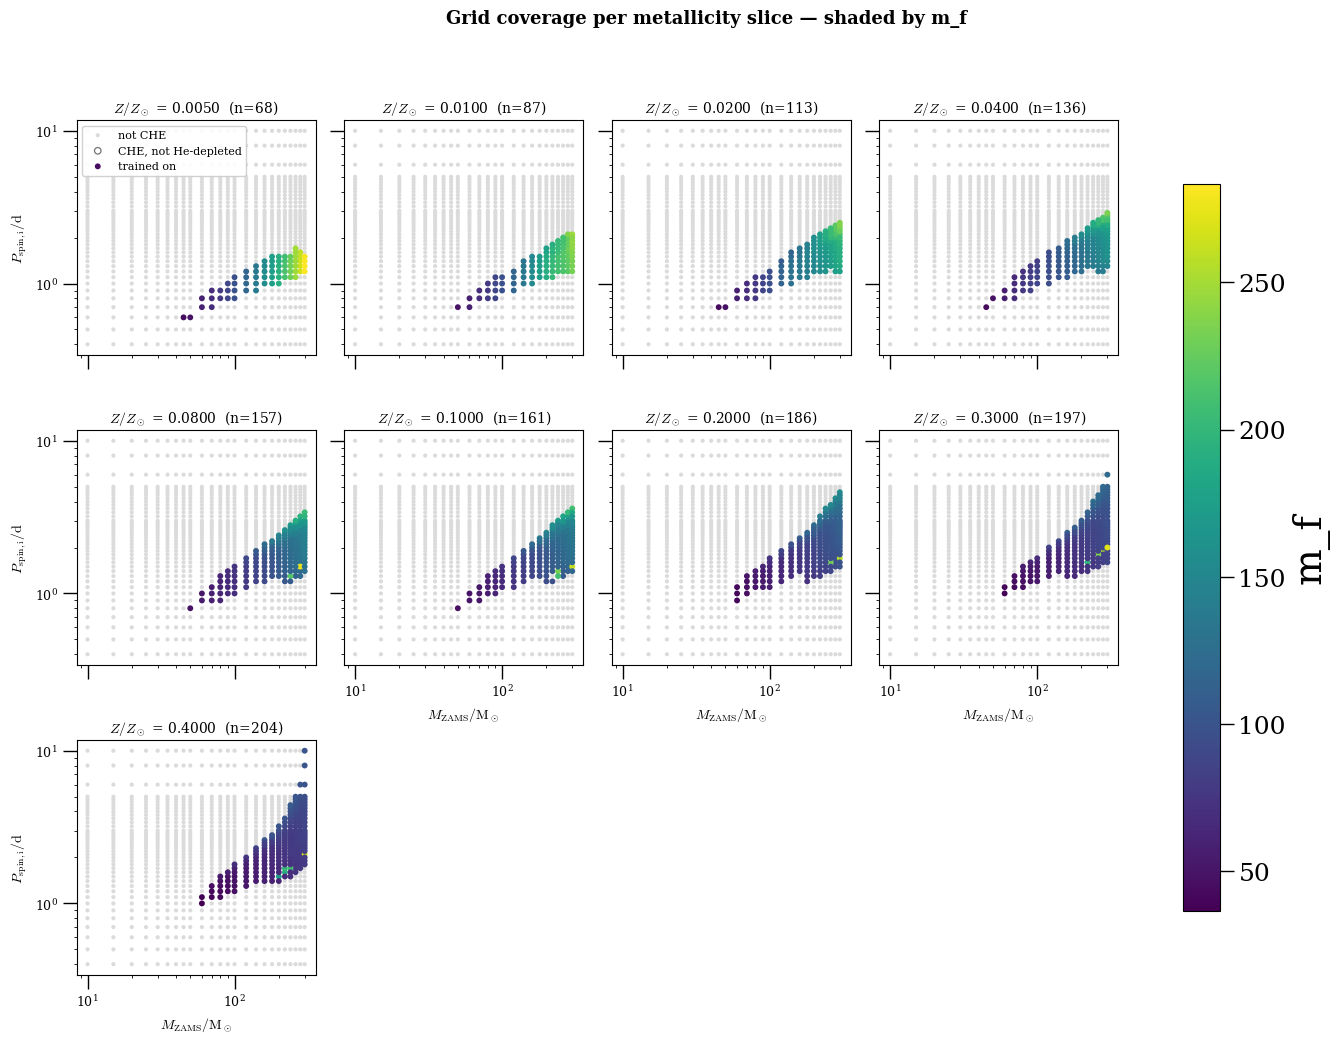

In [10]:
fig, axs = plot_pmz_grid_coverage(core_props_df, var='m_f', cut_non_he_depl=False)
for ax in axs.ravel():
    ax.set_yscale('log')
    ax.set_xscale('log')

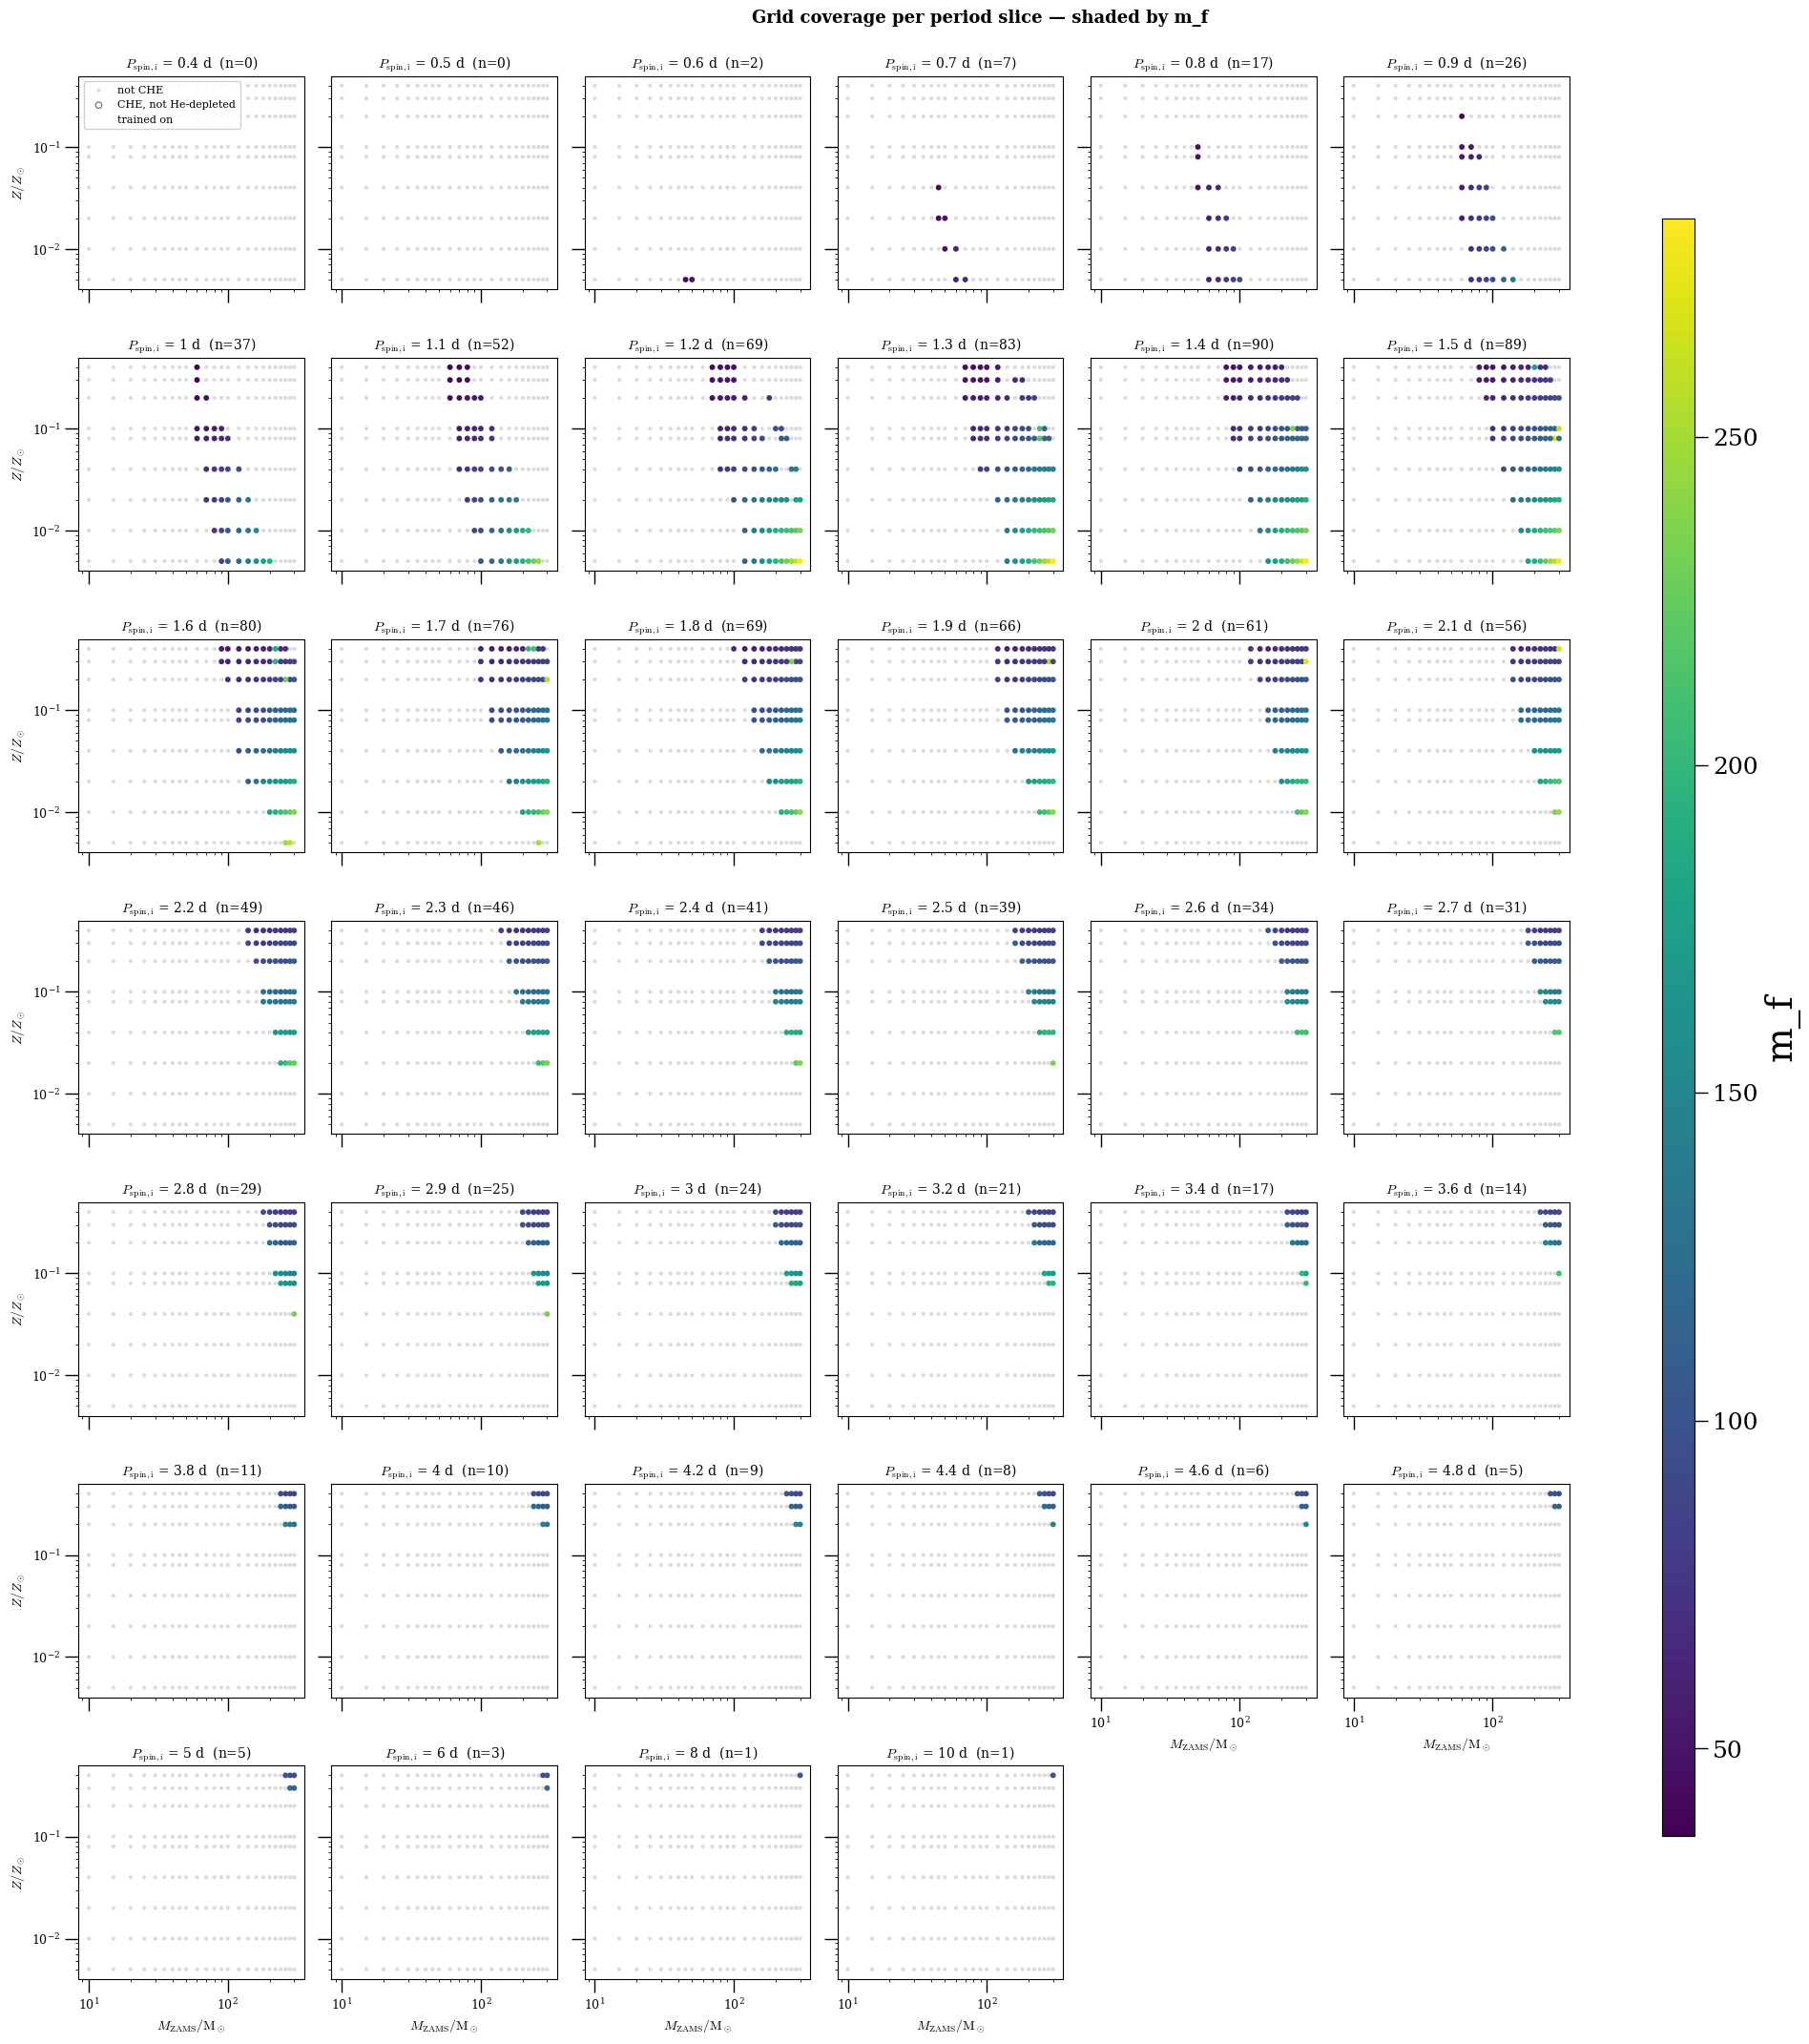

In [11]:
fig, axs = plot_pmz_grid_coverage_by_period(core_props_df, var='m_f', cut_non_he_depl=False, ncols=6)
for ax in axs.ravel():
    ax.set_yscale('log')
    ax.set_xscale('log')

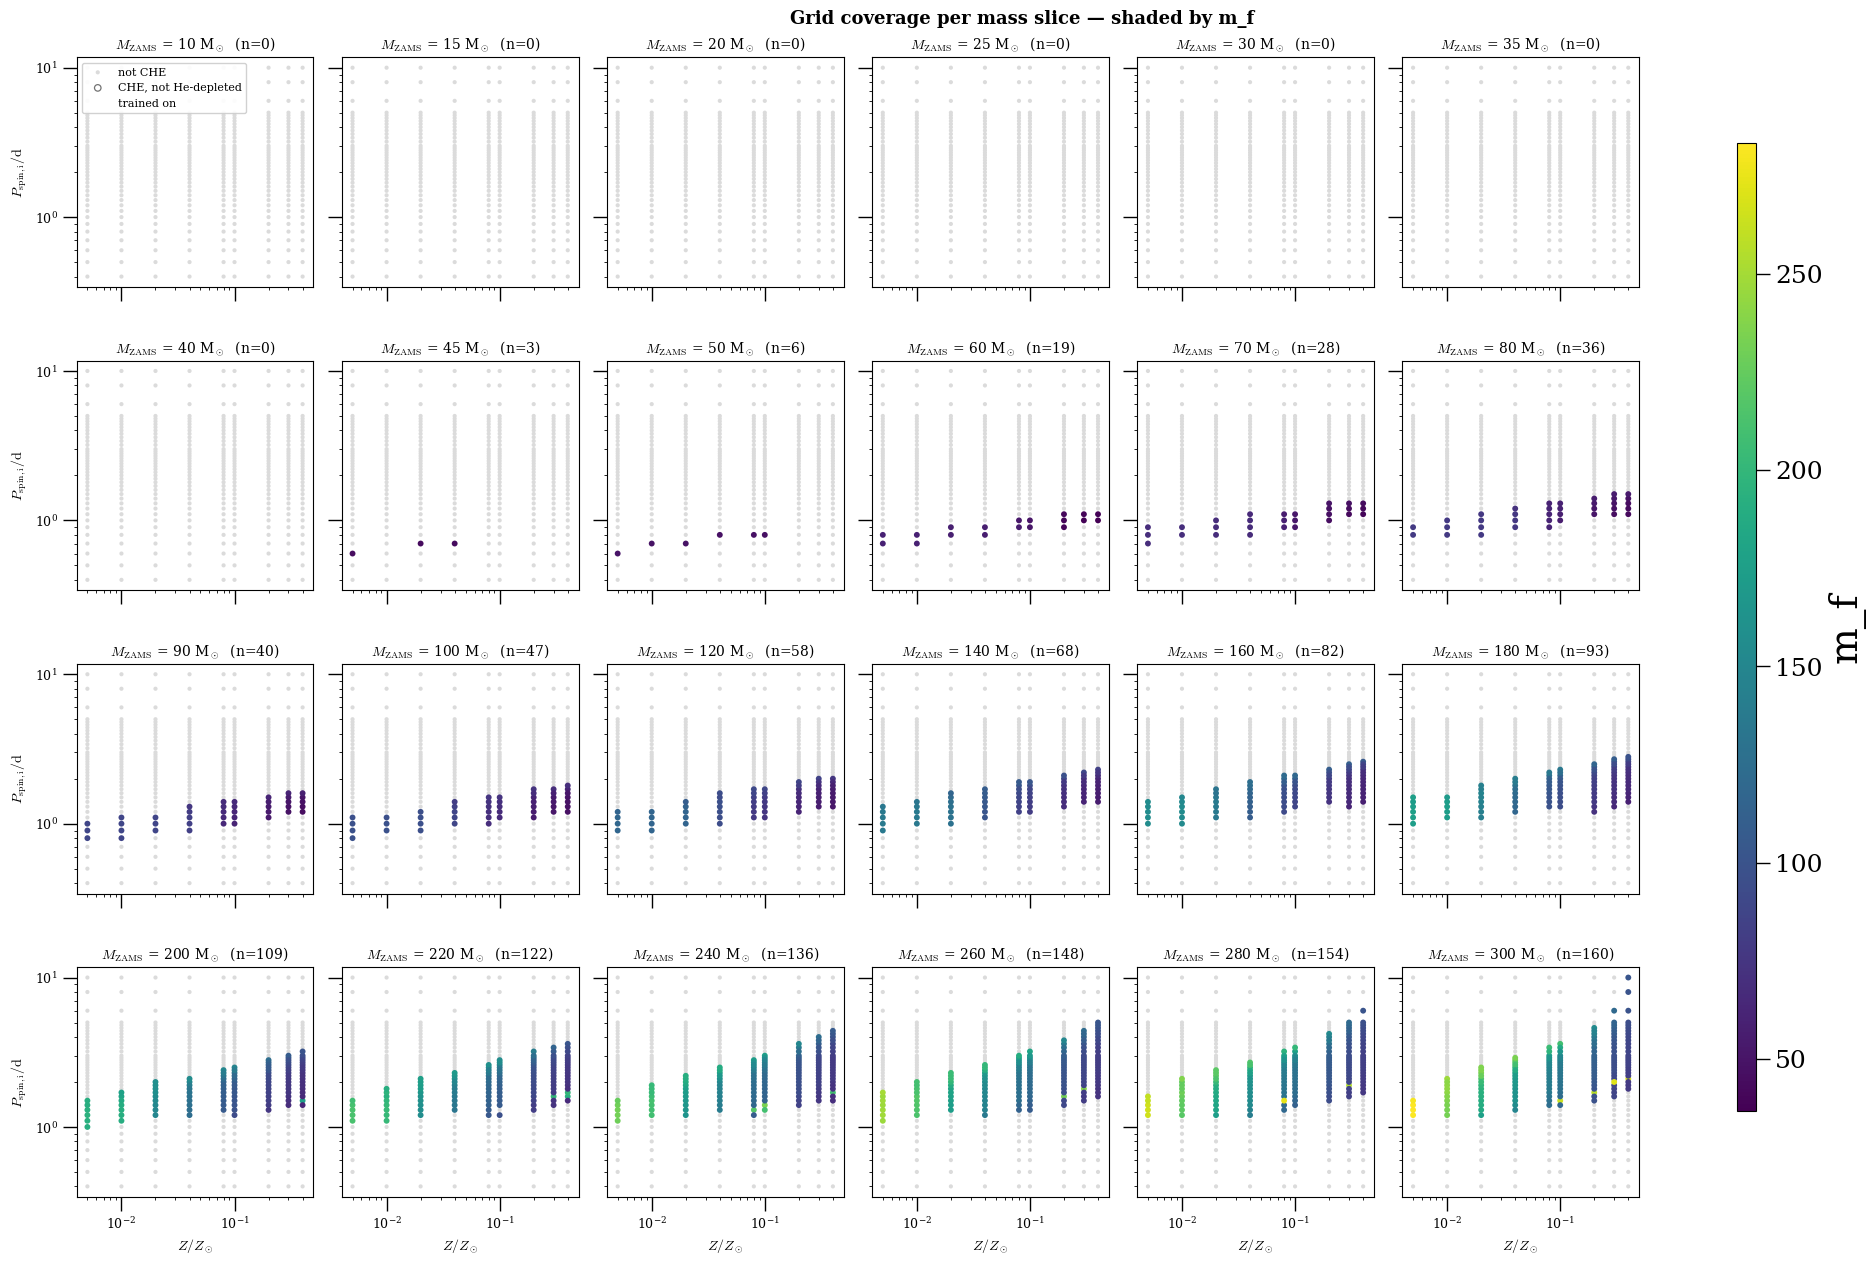

In [12]:
fig, axs = plot_pmz_grid_coverage_by_mass(core_props_df, var='m_f', cut_non_he_depl=False, ncols=6)
for ax in axs.ravel():
    ax.set_yscale('log')
    ax.set_xscale('log')

### 2.2 Data X Interpolator over P, M, Z slices

Check that map grid results are reasonably well behaved. The interpolator is never actually used on the map grid for producing results, but we implement it below as a visual guide.

In [13]:
# Set up interpolator without cutting non He depl, otherwise it will ignore the entire map grid.
ip_models = {
    var: PMZLinearInterpolator(
        core_props_df, var=var, cut_non_he_depl=False, extrapolate_z_islands=True,
    )
    for var in PIPELINE_VARS
}

/tmp/ipykernel_536494/1279710887.py:3: UserWarning: [PMZLinearInterpolator var=m_f] 9 (m, p) column(s) whose valid metallicities form one run reaching neither metallicity global minimum nor maximum. Is this a broad CHE window cusp or error? Interpolator will continue. Cells: (45, 0.7, XXOOXXXXX), (50, 0.7, XOOXXXXXX), (50, 0.8, XXXOOOXXX), (60, 0.9, XXOOOOOXX), (70, 1, XXOOOOOXX), (80, 1, XOOOOOXXX), (90, 1.1, XOOOOOOXX), (300, 1.6, XOOOOOOOX), ... (+1 more)
  var: PMZLinearInterpolator(
/tmp/ipykernel_536494/1279710887.py:3: UserWarning: [PMZLinearInterpolator var=m_f] 7 (m, p) column(s) whose valid metallicities form two or more separate runs. Check input data for crashed CHE cases. Interpolator will smooth over gaps. Cells: (160, 1.3, OOOOOOXOX), (180, 1.2, OOOOXXOXX), (200, 1.2, OOOOXOXXX), (220, 1.2, OOOXOOXXX), (220, 1.3, OOOOOXOXX), (240, 1.2, OOOXOXXXX), (260, 1.2, OOXOXXXXX)
  var: PMZLinearInterpolator(


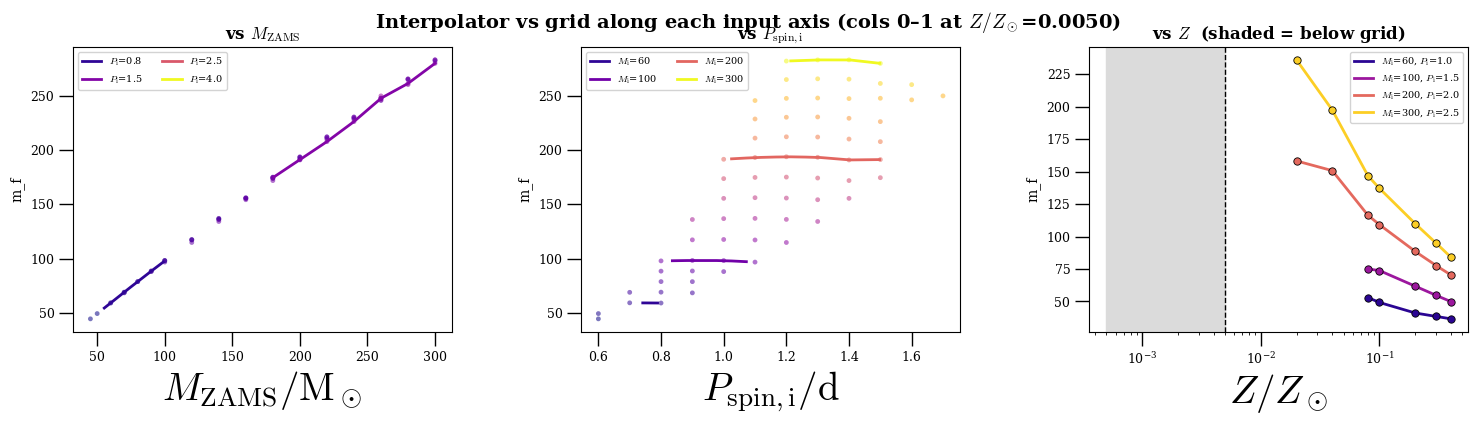

In [14]:
fig, axs = plot_pmz_axis_slices(
    ip_models, core_props_df,
    p_probes=(0.8, 1.5, 2.5, 4.0),
    m_probes=(60.0, 100.0, 200.0, 300.0),
    mp_probes=((60.0, 1.0), (100.0, 1.5), (200.0, 2.0), (300.0, 2.5)),
    z_range=(5e-4, 0.4),
    z_key_for_mp=Z_KEYS[0],
    cut_non_he_depl=False,
)

Note the spike in for period 2. While this is a sign of an issue with those models, it does not affect the creation of the sparse grid since 1) it does not affect the shape of the window and 2)it is smoothed over by enforced monotonicity on m_f(p_i) by the sparse grid creator. 

#### 3 Sparse grid evaluation

In [ ]:
core_props_df = get_complete_core_props_df(DATA_DIR/'01_weakmix_core_props_df_v7.h5')
model_name = '01_weakmix'

#### 3.1 Grid coverage

Check captured CHE window shape, mostly smooth final mass behavior.

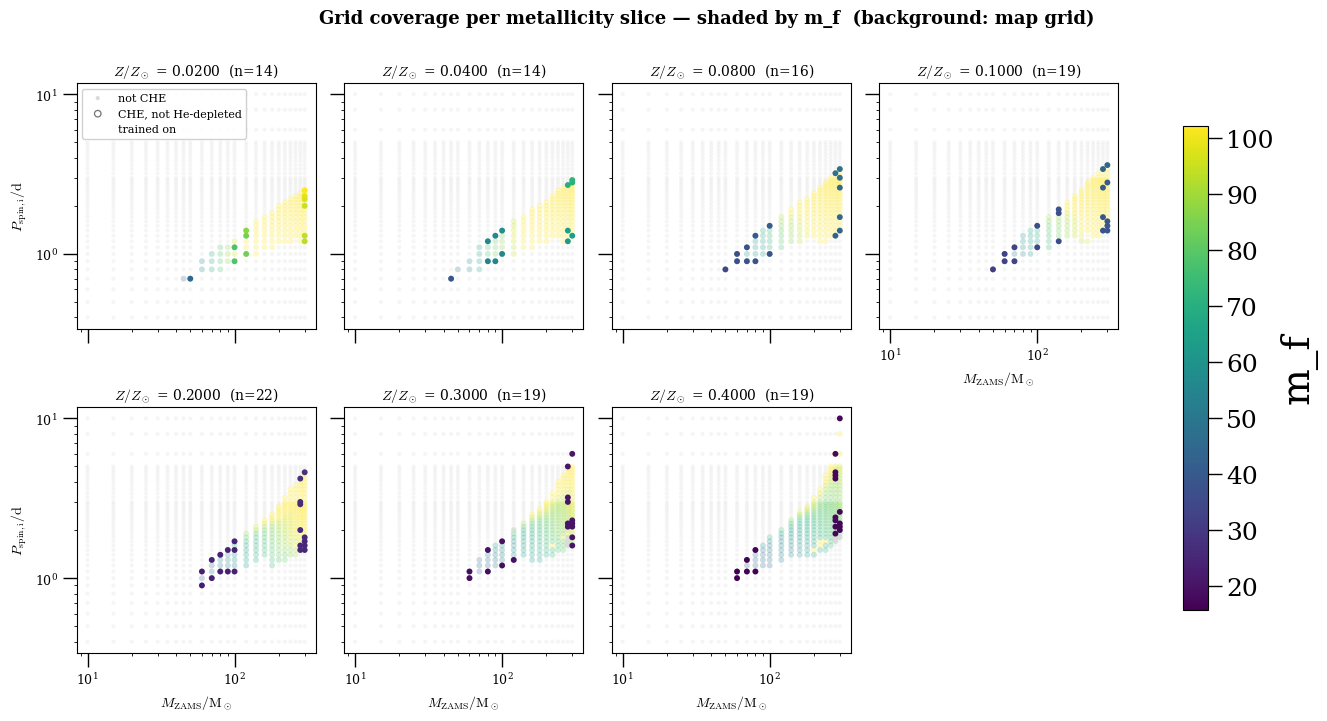

In [16]:
fig, axs = plot_pmz_grid_coverage(
    core_props_df, var='m_f', cut_non_he_depl=False,
    background_df=map_core_props_df, background_alpha=0.25, background_label='map grid',
)
for ax in axs.ravel():
    ax.set_yscale('log')
    ax.set_xscale('log')

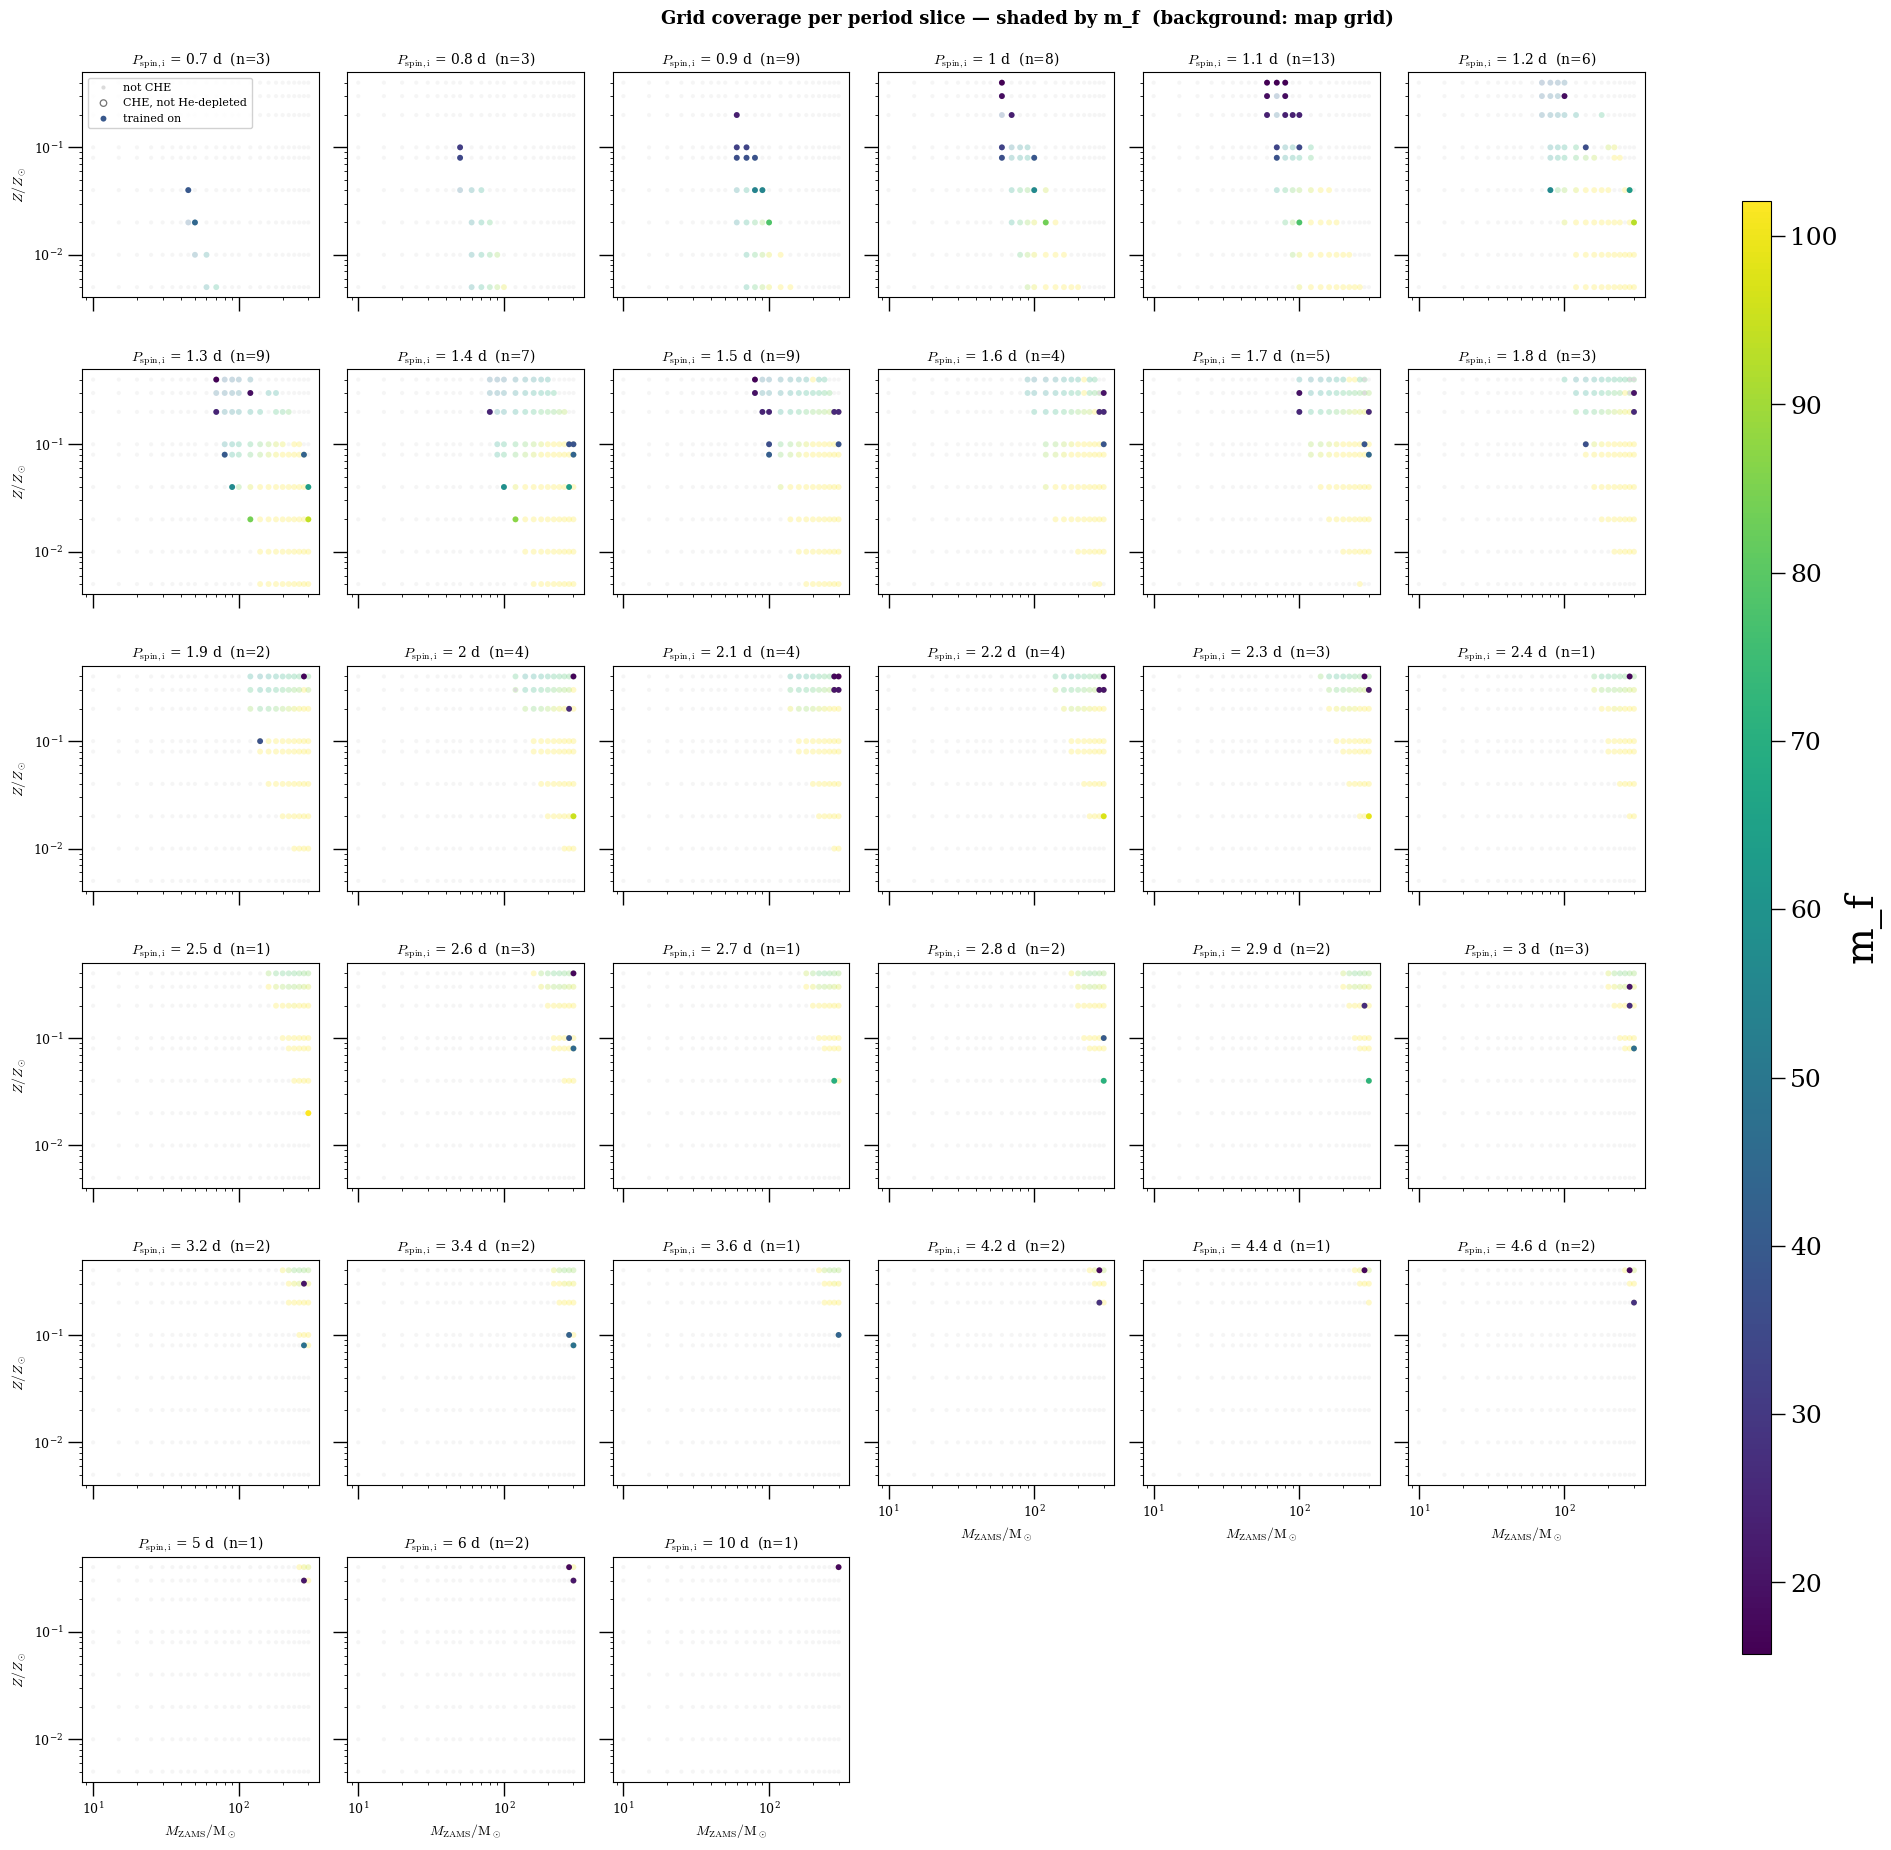

In [17]:
fig, axs = plot_pmz_grid_coverage_by_period(
    core_props_df, var='m_f', cut_non_he_depl=False, ncols=6,
    background_df=map_core_props_df, background_alpha=0.25, background_label='map grid',
)
for ax in axs.ravel():
    ax.set_yscale('log')
    ax.set_xscale('log')

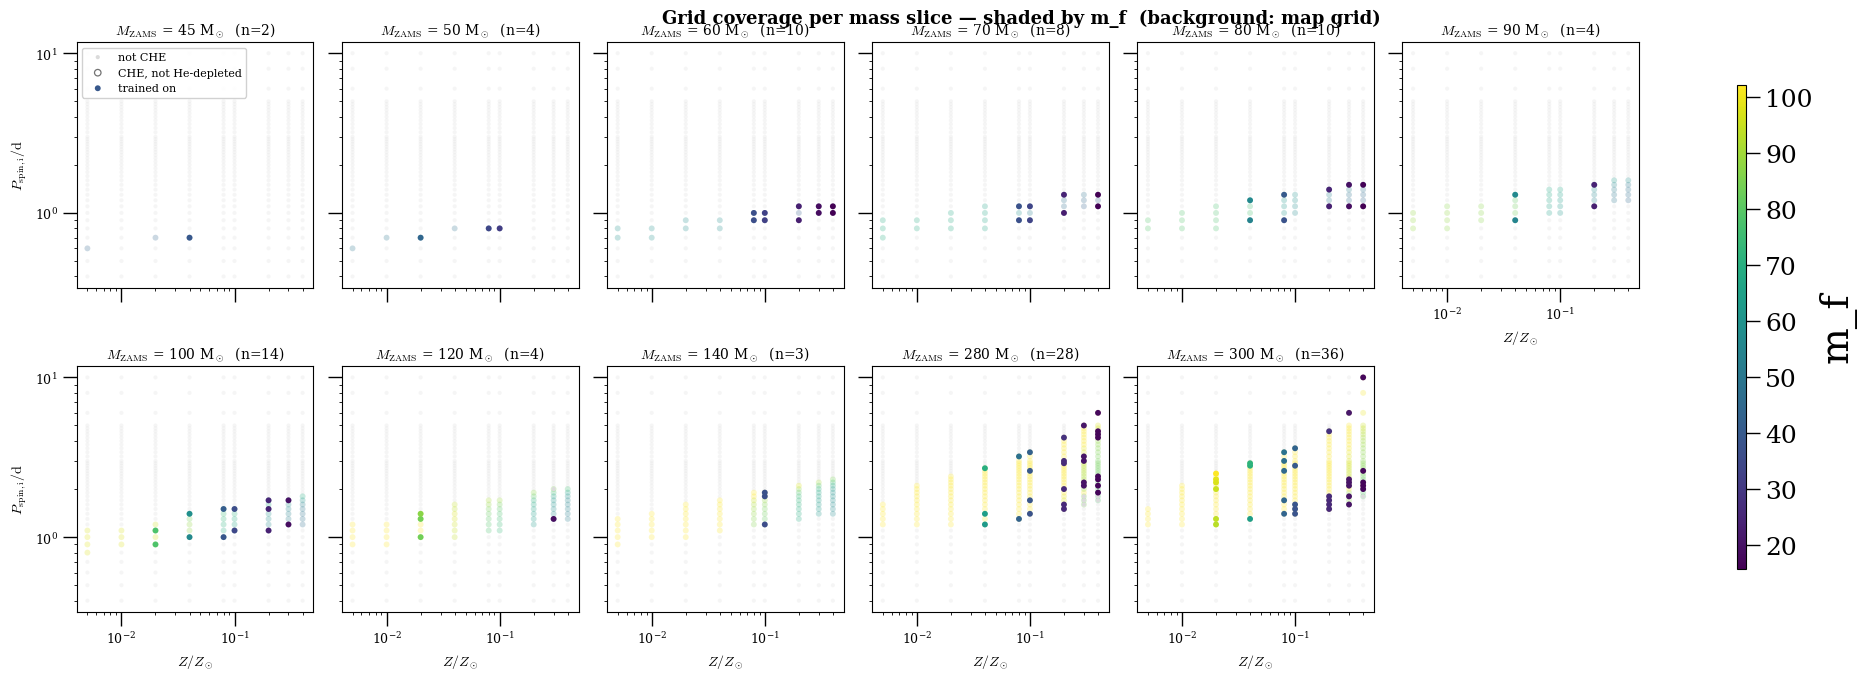

In [18]:
fig, axs = plot_pmz_grid_coverage_by_mass(
    core_props_df, var='m_f', cut_non_he_depl=False, ncols=6,
    background_df=map_core_props_df, background_alpha=0.25, background_label='map grid',
)
for ax in axs.ravel():
    ax.set_yscale('log')
    ax.set_xscale('log')

### 3.2 Data X Interpolator over P, M, Z slices

Check that map grid results are reasonably well behaved. The interpolator is never actually used on the map grid for producing results, but we implement it below as a visual guide.

In [20]:
# Set up interpolator without cutting non He depl, otherwise it will ignore the entire map grid.
ip_models = {
    var: PMZLinearInterpolator(
        core_props_df, var=var, cut_non_he_depl=False, extrapolate_z_islands=True, interpolate_diagonals=True, map_core_props_df=map_core_props_df,
    )
    for var in PIPELINE_VARS
}

/tmp/ipykernel_536494/1350003069.py:3: UserWarning: [PMZLinearInterpolator var=m_f] 26 isolated CHE node(s): no CHE neighbour among the 8 in-plane cells at the same metallicity. Are these crashed neighbors? Interpolator will continue. Cells: (45, 0.7, 0.0400), (50, 0.7, 0.0200), (70, 1.3, 0.4000), (80, 1.1, 0.3000), (80, 1.3, 0.0800), (80, 1.5, 0.3000), (80, 1.5, 0.4000), (100, 1, 0.0800), ... (+18 more)
  var: PMZLinearInterpolator(
/tmp/ipykernel_536494/1350003069.py:3: UserWarning: [PMZLinearInterpolator var=m_f] 44 (m, p) column(s) whose valid metallicities form one run reaching neither metallicity global minimum nor maximum. Is this a broad CHE window cusp or error? Interpolator will continue. Cells: (45, 0.7, XOXXXXX), (50, 0.8, XXOOXXX), (60, 0.9, XXOOOXX), (70, 0.9, XXOOXXX), (70, 1, XXXXOXX), (80, 0.9, XOOXXXX), (80, 1.2, XOXXXXX), (80, 1.3, XXOXXXX), ... (+36 more)
  var: PMZLinearInterpolator(
/tmp/ipykernel_536494/1350003069.py:3: UserWarning: [PMZLinearInterpolator var=m_f

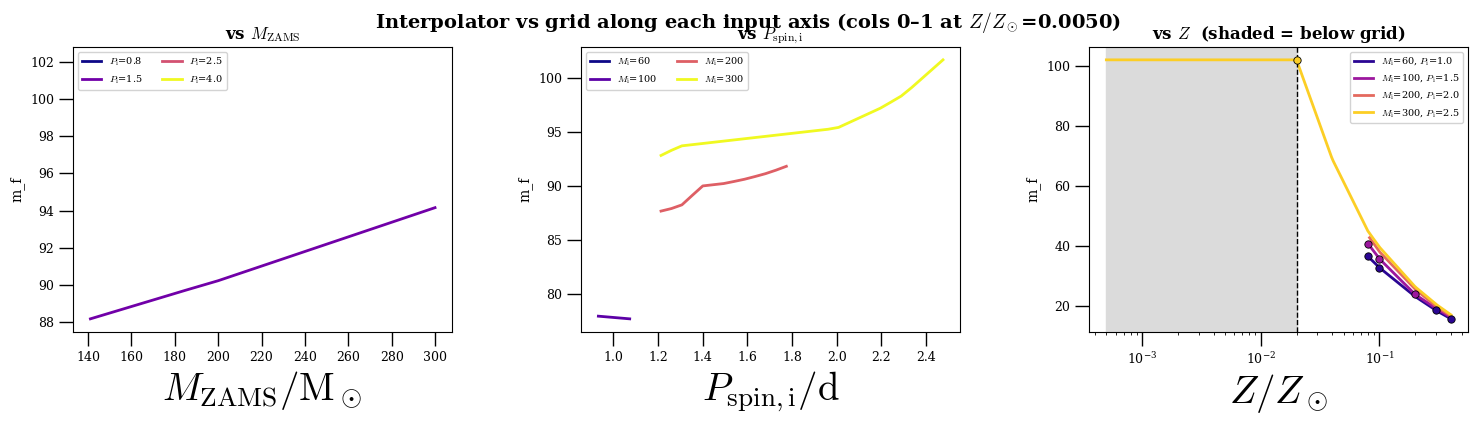

In [21]:
fig, axs = plot_pmz_axis_slices(
    ip_models, core_props_df,
    p_probes=(0.8, 1.5, 2.5, 4.0),
    m_probes=(60.0, 100.0, 200.0, 300.0),
    mp_probes=((60.0, 1.0), (100.0, 1.5), (200.0, 2.0), (300.0, 2.5)),
    z_range=(5e-4, 0.4),
    z_key_for_mp=Z_KEYS[0],
    cut_non_he_depl=False,
)

### 3.3 Interpolator fill vs map grid

Variation of the section 3.1 grid-coverage panels: instead of scattering the sparse grid's own points, evaluate the interpolator fitted on the sparse grid over the wider (M, P) space the map grid spans, per metallicity. The map grid's points and its per-mass window envelope are drawn on top for reference — gaps between the envelope and the filled colour mark where the interpolator either has no training data to reach, or disagrees with the map grid's actual window shape (e.g. sub-grid Z extrapolation).

CPU times: user 3.72 s, sys: 4.6 s, total: 8.32 s
Wall time: 21.8 s


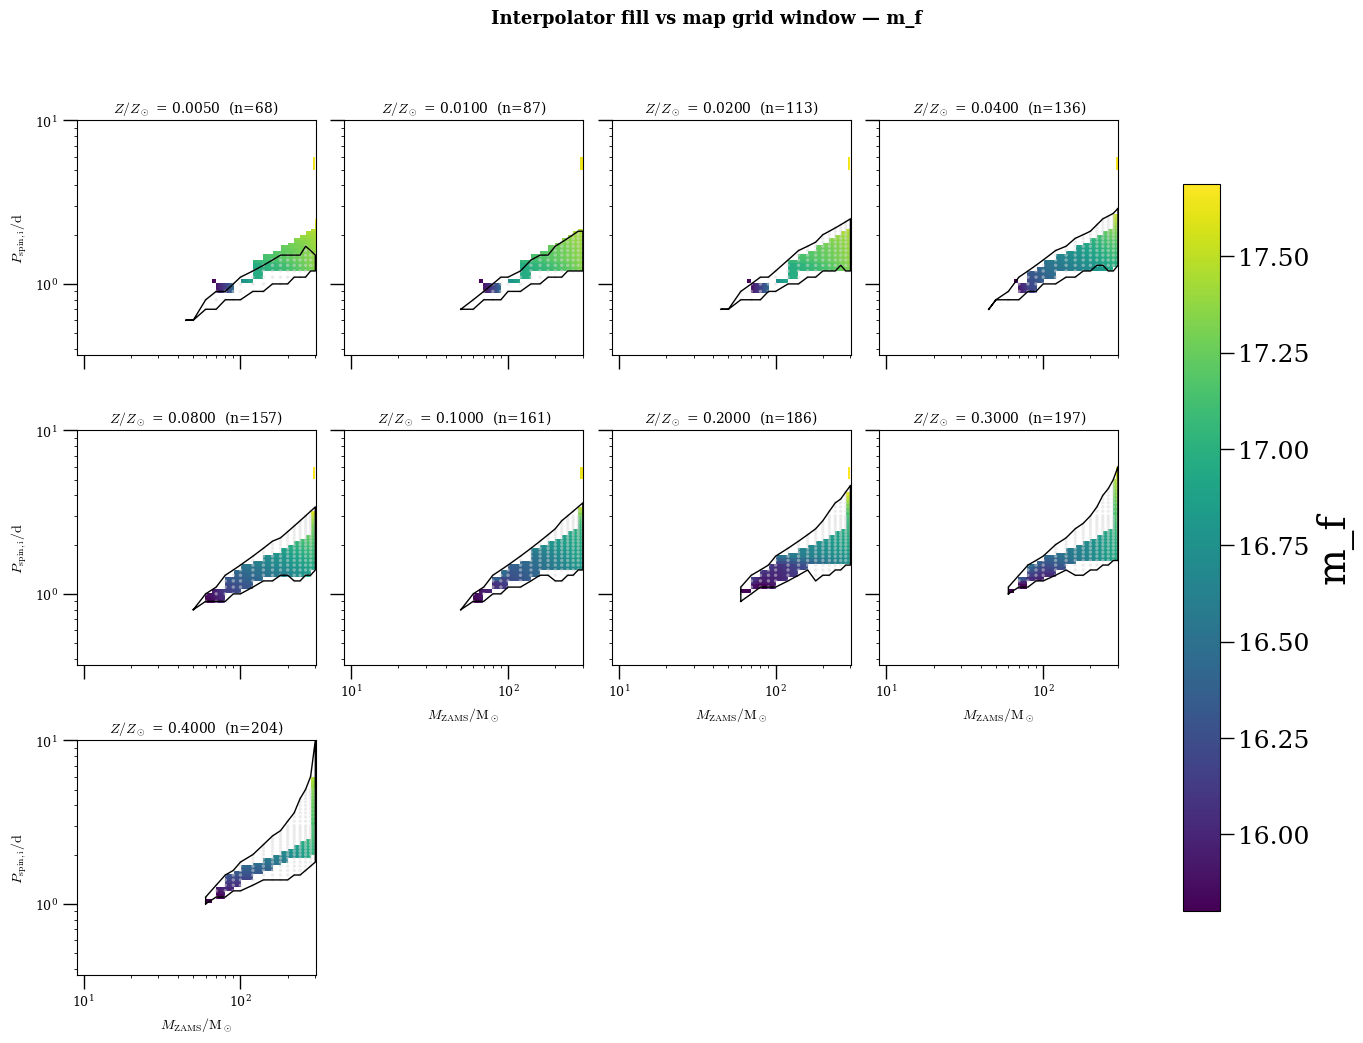

In [22]:
%%time
fig, axs = plot_pmz_interpolator_fill(ip_models['m_f'], map_core_props_df, n_cpu=30)
for ax in axs.ravel():
    ax.set_yscale('log')
    ax.set_xscale('log')

Note the spike in for period 2. While this is a sign of an issue with those models, it does not affect the creation of the sparse grid since 1) it does not affect the shape of the window and 2)it is smoothed over by enforced monotonicity on m_f(p_i) by the sparse grid creator. 

## 4 CHE window shape across grids

Compare the CHE window shape captured by every available grid: the fiducial dense grid plus every physics-variation map grid (map grids are used specifically to trace the CHE window edges, see section 2). Each window is drawn as the convex hull, per metallicity, of that grid's CHE points in (M_ZAMS, P_spin,i).

In [51]:
GRID_PATHS = {'00_fiducial': DATA_DIR / '00_fiducial_core_props_df_v7.h5'}
for p in sorted(DATA_DIR.glob('[0-9][0-9]_*_core_props_df_map_v7.h5')):
    model = p.name.removesuffix('_core_props_df_map_v7.h5')
    GRID_PATHS[model] = p

all_grids = {name: get_complete_core_props_df(path) for name, path in GRID_PATHS.items()}
print('Loaded grids:', list(all_grids.keys()))

Loaded grids: ['00_fiducial', '01_weakmix', '02_strongmix']


### 4.1 One panel per grid

Each panel is a single grid's full M,P coverage (faint grey background), with one CHE-window polygon per metallicity, coloured along viridis.

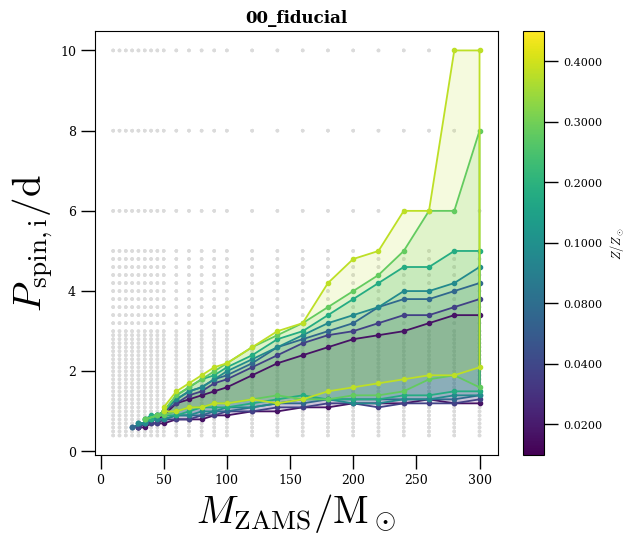

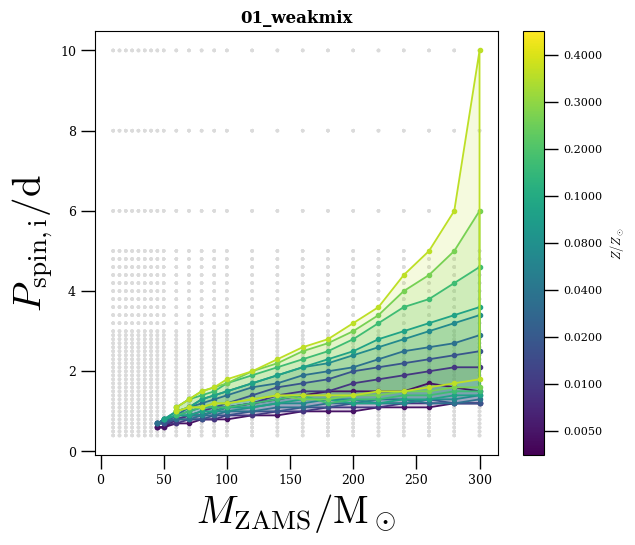

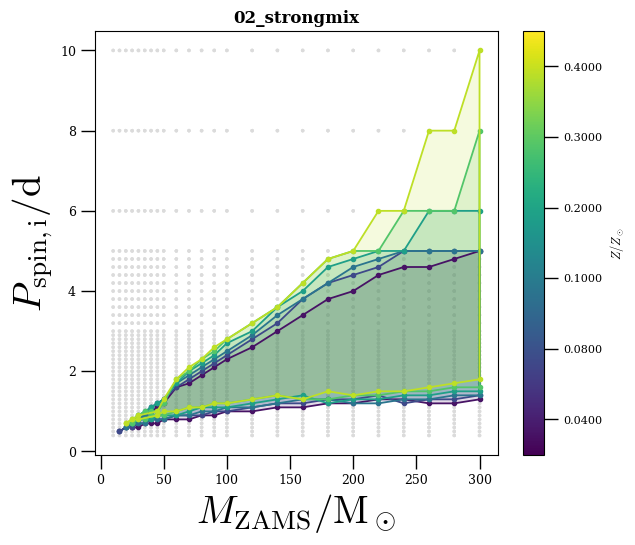

In [52]:
for name, df in all_grids.items():
    fig, ax = plot_che_window_hull(df, title=name)

### 4.2 One panel per metallicity

Each panel is one metallicity; every grid's CHE-window polygon for that Z is overlaid in the same panel, one colour per grid.

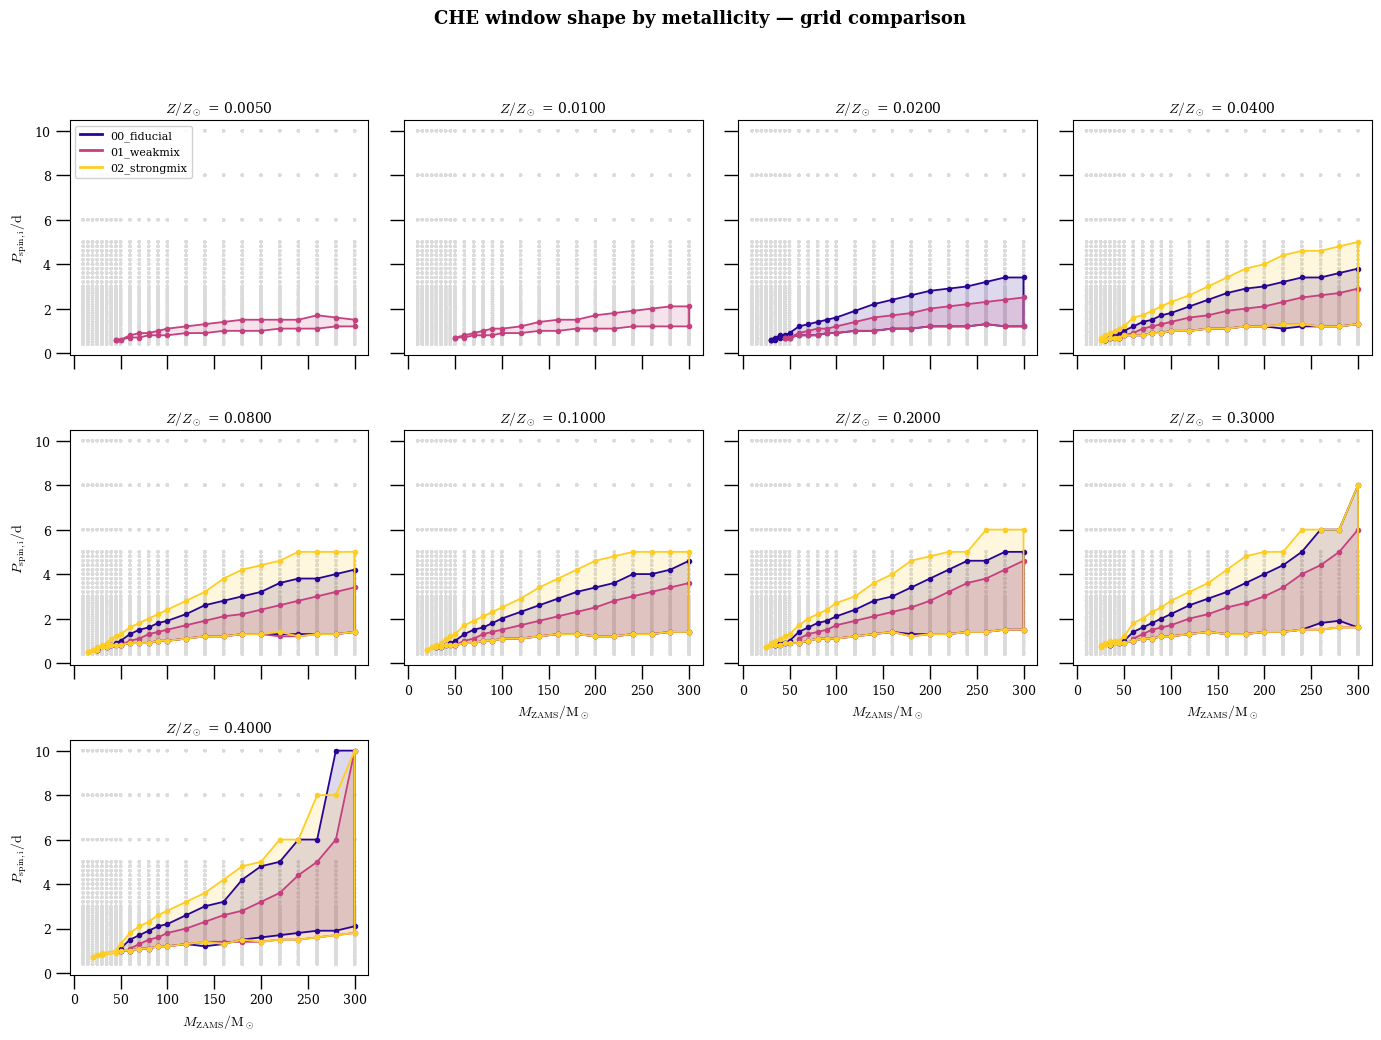

In [53]:
fig, axs = plot_che_window_hull_by_metallicity(all_grids)